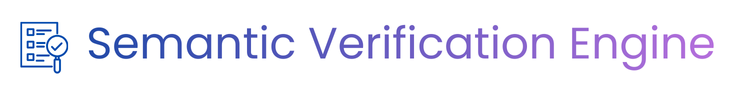

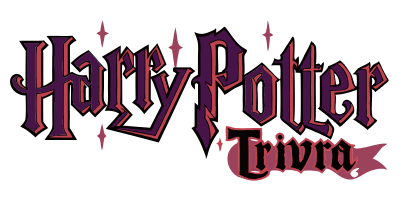

<div style="background-color: #f0e6f7; padding: 10px;">
    <h2 style="text-align:center; color:purple;">Harry Potter Trivia Game</h2>
    <h3 style="text-align:center; color:purple;">Data preparation and EDA</h3>
</div>

# 1: Introduction

This work is part of a two-notebook series focused on preparing and exploring a Harry Potter trivia dataset for use in the Command-Line Interface (CLI) MVP. Across the series, the raw data is cleaned and standardized, its suitability for gameplay is evaluated, and keyword features are generated to support deeper analysis. The dataset is sourced from [saracandu/harry-potter-trivia-human](https://huggingface.co/datasets/saracandu/harry-potter-trivia-human/tree/main) on Hugging Face, downloaded on January 25, 2025 using the download_data.py script. The train and test splits were combined into a single CSV for processing.

### Scope of the notebook

This first notebook covers data cleaning, initial exploratory analysis, and keyword generation—laying the groundwork for later notebook that will perform more detailed analysis and finalize the baseline dataset for direct use in the game. The aim is to perform initial cleaning and exploratory analysis to understand what the data contains, how it’s structured, and where it may need refinement for gameplay. The work here covers three key steps:

1. **Data cleaning and preparation**: Handle null values, remove duplicates, correct data types, and select relevant features to ensure a consistent and usable dataset.
2. **Initial EDA**: Explore the cleaned dataset to assess question quality, identify potential categories, examine question–answer relationships, and surface patterns relevant to game design through descriptive statistics and N-gram analysis.
3. **Keyword generation**: Tokenize and lemmatize the text in questions and answers to create a preliminary set of keyword features for more detailed analysis in later work.

# Table of Contents

1. [Introduction](#1-introduction)<br>
2. [Glossary of key terms](#2-glossary-of-key-terms)<br>
3. [Setup and imports](#3-setup-and-imports)<br>
4. [Data preparation](#4-data-preparation)<br>
5. [**Basic Exploratory Data Analysis (EDA)**](#5-basic-eda-of-the-cleaned-dataset)<br>
    5.1. [Question and answer length distributions](#51-question-and-answer-length-distributions)<br>
    5.2. [Answer lengths and diversity](#52-answer-lengths-and-diversity)<br>
    5.3. [Question lengths](#53-question-lengths)<br>
    5.4. [Question and answer length correlations](#54-question-and-answer-length-correlation)<br>
6. [**Keyword feature engineering**](#6-keyword-feature-engineering) <br>
7. [**EDA based on keywords**](#7-eda-based-on-keywords)<br> 
    7.1. [Overall keyword frequnecy](#71-overall-keyword-frequency) <br>
    7.2. [Factual recall questions](#72-factual-recall-questions)<br>
    7.3. [Questions that do not have factual-recall keywords](#73-questions-that-do-not-have-factual-recall-keywords)<br>
    7.4. [Correlation summary: Q&A lengths by question keyword](#74-correlation-summary-of-qa-lengths-by-keyword)<br>
    7.5. [N-grams analysis of thematic content](#75-n-gram-analysis-of-thematic-content)<br>
8. [**Summary of cleaning and EDA**](#8-summary-of-cleaning-and-eda)<br>
    8.1. [Key findings and outcomes](#81-key-findings-and-outcomes)<br>
    8.2. [Next steps and recommendations](#82-next-steps-and-recommendations)<br>

# 2: Glossary of key terms

To ensure clarity and consistency, the following terms are defined within the context of this analysis:

|Term | Abbreviation | Description|
|-|-|-|
|Factual Recall (Question) | FR | Question seeking specific objective info (name, date, place, etc.). Identified by keywords such as 'What', 'Who', etc. |
| Open-Ended Question| OEQ| Question seeking explanation, opinion, or procedure, often identified by keywords like 'Why' or 'How'.|
| Question Type| QT | Classification assigned (e.g., Factual-Recall, Open-Ended) based primarily on keywords/phrasing, answer type |
| Question Keyword | QK | Lemmatized token from question text used for analysis/filtering (standard stopwords removed, interrogatives kept). |
| MVP of game| CLI-MVP | The first phase prototype of the Harry Potter Trivia game (Command Line Interface - Minimum Viable Product) |  

# 3: Setup and imports

Import the necessary external packages as well as internal project environment configuration and custom helper and utility methods from project modules.

In [1]:
#  STANDARD NOTEBOOK SETUP
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')
import json
# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# --- Project-Specific Imports ---
import notebook_support.notebook_config as nb_cfg
from notebook_support import eda_scripts as eda
from notebook_support import obsolete_scripts as obs
# --- Common Settings ---
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)

✅ Notebook config loaded.


In [2]:
# --- Notebook-Specific Imports ---
import re
from collections import Counter
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
# custom tokenizer from project ds utils
from notebook_support.text_processing import tokenize_text
from notebook_support.obsolete_scripts import tokenize_text_v0_obsolete
from notebook_support import obsolete_scripts as obsolete
from notebook_support import ds_constants as const

<a href="#toc" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 4: Data preparation

To start, the dataset quality needs be to checked and addressed suitably. These involves checking the size of the dataset to make sure there are enough questions, as well as missing data (nulls) and duplicates. 

In [3]:
# convert csv file to dataframe
raw_csv_path = nb_cfg.RAW_DATA_DIR / "trivia_dataset_v0_raw.csv"

raw_df = pd.read_csv(raw_csv_path)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1279 non-null   object
 1   answer    1279 non-null   object
 2   text      1279 non-null   object
dtypes: object(3)
memory usage: 30.1+ KB


The dataset has 1279 rows and 3 columns. 

In [4]:
raw_df.sample(5)

,question,answer,text
272,Who would make the most use of the charm Aloho...,A Thief,<s>[INST] Who would make the most use of the c...
478,Colovaria is also known as what?,Colour Change Charm,<s>[INST] Colovaria is also known as what? [/I...
107,Madam Hooch has distinct yellow what?,Eyes,<s>[INST] Madam Hooch has distinct yellow what...
348,Who wrote the book Curses and Counter-Curses?,Viridian,<s>[INST] Who wrote the book Curses and Counte...
213,How old was Harry when he got his first letter...,Eleven,<s>[INST] How old was Harry when he got his fi...


The question and answers are in the first two columns. The third `text` column looks like it is the question and answers tokenized for LLM modelling.  Let's look a the full entry of the `text` column in the first row to see if it can be useful.

In [5]:
# Look at the contents of the first row, third column record (i.e. text column) without being clipped.
print(raw_df.iloc[0,2])  

<s>[INST] What are the three European wizarding schools that participate in the Triwizard Tournament? [/INST] Hogwarts, Beauxbatons, and Durmstrang. </s>


This confirms that the third column combines the question and answer with tokens for prompting an LLM model. It is not needed for this project, so the third column can be removed.

In [6]:
# Drop the `text` column:
raw_df = raw_df.drop(columns=['text'])
# Sanity check - confirm column has been dropped
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1279 non-null   object
 1   answer    1279 non-null   object
dtypes: object(2)
memory usage: 20.1+ KB


We can now check if there are any nulls in the dataset?

In [7]:
# check for nulls
print(f'Total number of nulls: ', raw_df.isna().sum().sum())
# check for duplicates
print(f'Total number of duplicates: ', raw_df.duplicated().sum())

Total number of nulls:  0
Total number of duplicates:  194


So no empty / missing values. However, there are 194 duplicates in the dataset. We can confirm this by taking a closer look at the rows and how many times they appear in the dataset and then delete them.

In [8]:
# Find duplicates based on all columns
duplicates = raw_df[raw_df.duplicated(keep=False)]
# Count occurrences of each duplicate row
duplicate_counts = duplicates.groupby(duplicates.columns.tolist()).size().reset_index(name='Count')
# Display the counts of each duplicate
print(duplicate_counts)

                                             question           answer  Count
0                       A Firebolt is a type of what?            Broom      5
1                         A Nimbus is a type of what?            Broom      5
2   According to Madam Hooch, which of the followi...        Long hair      5
3   Before Dumbledore, who was Headmaster of Hogwa...   Armando Dippet      2
4        Catching what object ends a Quidditch match?    Golden Snitch      5
..                                                ...              ...    ...
64  Who previously held Snape's post as Potions Ma...  Horace Slughorn      2
65                  Who previously held Snape's post?  Horace Slughorn      2
66  Who was the first witch or wizard to hatch a b...   Herpo the Foul      2
67        Why would you need to switch brooms midair?    Broom failure      5
68  You wouldn't know anything about this. Name a ...     Using polish      5

[69 rows x 3 columns]


So let's go ahead and delete the unnecessary duplicate rows. We should also convert the `question` and `answer` columns to `str` for clarity, type safety, and  to make sure the `str` methods are available for the columns.

In [9]:
# Drop duplicate rows
trivia_df = raw_df.drop_duplicates(keep='first').reset_index(drop=True)
print(f'Dataset shape after dropping duplicate rows: ', trivia_df.shape)

# convert columns from 'object` to `str`
trivia_df = trivia_df.astype({
    'question': 'string',
    'answer': 'string'})
print("\nData types after conversion:")
trivia_df.info()

Dataset shape after dropping duplicate rows:  (1085, 2)

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1085 non-null   string
 1   answer    1085 non-null   string
dtypes: string(2)
memory usage: 17.1 KB


After dropping the duplicates, we have 1085 unique questions and answer pairs in the dataset. A decent size for the MVP. We can have a quick look at the state of the cleaned dataframe and move on to exploration. 

In [10]:
trivia_df.head()

,question,answer
0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang."
1,When was Hogwarts founded?,10th century
2,What is a Wronski Feint?,Pretending to dive for the Snitch
3,You wouldn't know anything about this. Name a ...,Using polish
4,Harry first took the Knight Bus in The Prisone...,14 sickles.


# 5: Basic EDA of the cleaned dataset

We need to inspect and understand the dataset to decide whether it is suitable for the trivia game. Some questions we can  consider:
- Are there enough quality and diverse questions and answers?
- Does it cover a wide-enough range of Harry Potter content to make the game interesting?
- How verbose are the questions and answers? Are they grammatically correct and easy to understand?
- Are there various degrees of difficulty to the questions? 
- Could the length give an idea of the difficulty of the questions? What else?
- Do longer questions result in longer answers? 
- What type of questions are there? What about the answers? is categorization possible?
- Are there other patterns there?

We can start the data exploration by looking at the questions and answer columns analytically. One characteristic they have in common is length (ie. word count). We can look at the descriptive statistics and distributions of the lengths. We can tokenize the words and look at question types and N-grams to get contextual understanding of the questions and answers. And we can also look at the relationship between questions and answers. 

## 5.1: Question and answer length distributions

In [11]:
# extract the length of each question and answer using the helper function from the eda_scripts module
question_lengths = eda.get_clean_word_counts(trivia_df, "question")
answer_lengths = eda.get_clean_word_counts(trivia_df, "answer")

length_analysis = pd.DataFrame({"question": question_lengths, "answer": answer_lengths}).describe()
print(length_analysis)

          question       answer
count  1085.000000  1085.000000
mean      9.851613     2.659908
std       4.326515     2.657494
min       3.000000     1.000000
25%       7.000000     1.000000
50%       9.000000     2.000000
75%      12.000000     3.000000
max      31.000000    25.000000


The answers are generally shorter then the questions. Most answers are about 1 to 3 words while most questoins are about 9 words. 

We can also look at the distributions visually.

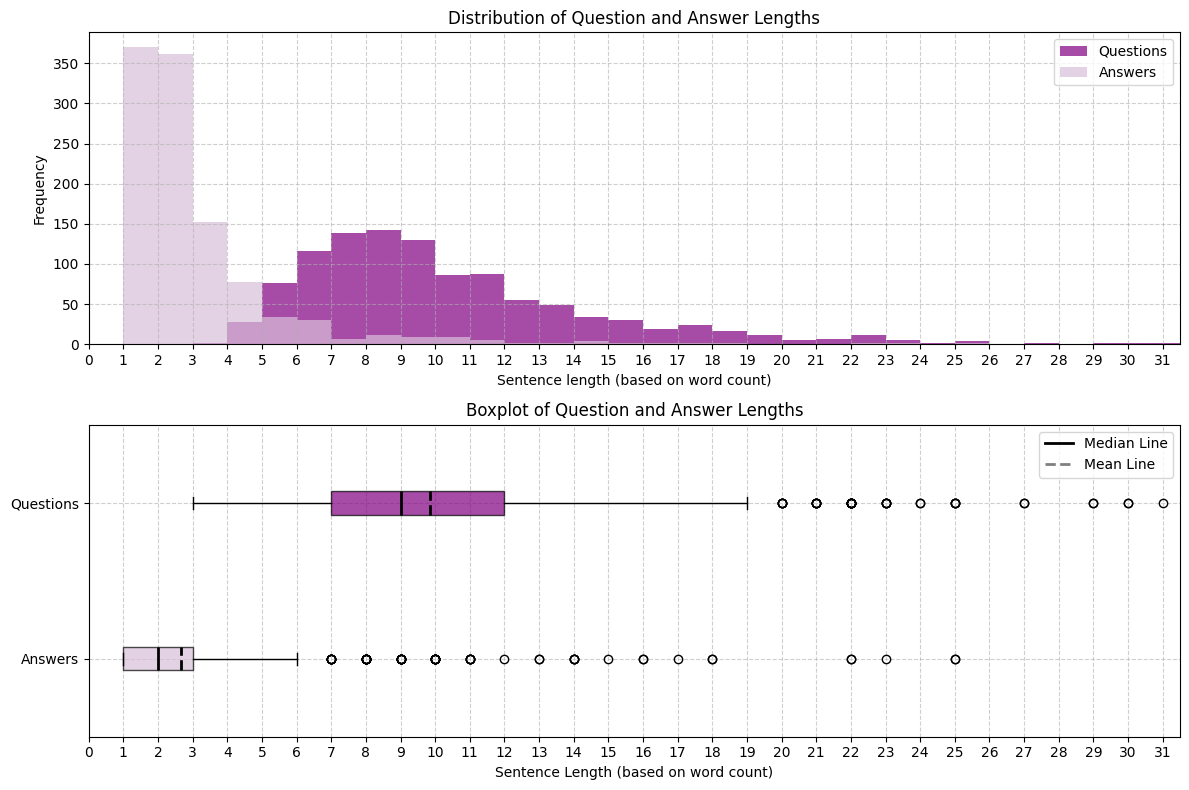

In [12]:
# let's plot the distribution of lengths of questions and answers
eda.plot_qa_len_distributions(question_lengths, answer_lengths)

From the plot above:
- Both questions and answers have longer sentences as outliers, perhaps they can be made more concise / clearer?
- The questions looks like a right-skewed normal distribution
- Most questions are ~12 words or less (75% percentile)
- Most questions fall between 7 and 12 words (inter-quartile range), with a mean of 9 words.
- The answers is also a very right-skewed distribution with a rapid decay.
- Most answers are ~3 words or less (75% percentile)
- One word answers are the most common.
- So the answers are generally short words that should make answer checking simpler.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.2: Answer lengths and diversity

The answers are the enagagement point with the players, so their handling makes up the heart of the game.
Characteristics of the answers in the dataset (the scoring guide) provide insights that inform both gameplay design and the technical requirements for our answer-checking system. The two main attributes to consider are the answer lengths and contextual diversity.

1. **Answer length** gives us a strong indication of expected player behavior. Questions with long, verbose answers will naturally invite more variation from players, while short, fact-based answers may require more straightforward string matching. To manage both effectively, we need a data-driven way to distinguish between them. Based on the descriptive statistics in [section 5.1](#51-overview), 75% of answers have 3 words or fewer (Q3 is 3 words) and an interquartile range (IQR) of 2. This confirms that the majority of answers are concise. Using the standard outlier detection formula, we can establish a preliminary threshold:
    - **Short answers:** 6 or fewer words (≤ Q3 + 1.5 * IQR),
    - **Long answers:**  7 or more words (> Q3 + 1.5 * IQR).

2. **Answer diversity**. A diverse set of answers covering a wide range of characters, spells, and places from the Harry Potter universe ensures a more immersive and less repetitive gameplay experience. It also helps gauge the topic difficulty and variety within the dataset. It is also important to check whether the diversity is "true" or simply syntactic. For example, answers like "Albus Dumbledore," "Professor Dumbledore," and "the headmaster" are syntactically different but semantically identical.

Together, these patterns in the answers will help inform us on whether the dataset is suitable for the game and subsequently, what approach to adopt to check the answers. 

So let's start by segregating the answers by length.

In [13]:
# Total number of answers:
total_answers = len(answer_lengths)

# Categorize word counts into bins:
bin_edges = [0, 3, 6, 11, np.inf]
bin_labels = ['1-3 words', '4-6 words', '7-11 words', '12+ words']
answer_length_bins = pd.cut(answer_lengths, bins=bin_edges,labels=bin_labels,right=True, # (x, y], upper limit is inclusive, lower is not
                            include_lowest=False) # Exclude 0 as wordcount

# Calculate frequencies and percentages for these bins
binned_counts = answer_length_bins.value_counts().sort_index()
binned_percentages = (binned_counts / total_answers) * 100
# Create a DataFrame for cleaner display of binned results
summary_bin_df = pd.DataFrame({'Count': binned_counts,'Percentage (%)': binned_percentages.round(2) })

# Display summary
print(" Summary of answer length frequencies:\n",
      '-'*60)
print(f'\nTotal number of answers analyzed: {total_answers}')
count_more_than_3 = binned_counts.get('4-6 words', 0) + binned_counts.get('7-11 words', 0) + binned_counts.get('12+ words', 0) 
print(f'The number of answers with a word count more than 3: {count_more_than_3}')
print("\nAnswer Length Distribution by Bins:")
display(summary_bin_df)
# Verify percentages add to ~100%
print(f'\nTotal Percentage (check): {binned_percentages.sum():.2f}%')

 Summary of answer length frequencies:
 ------------------------------------------------------------

Total number of answers analyzed: 1085
The number of answers with a word count more than 3: 201

Answer Length Distribution by Bins:


,Count,Percentage (%)
answer,,
1-3 words,884,81.47
4-6 words,142,13.09
7-11 words,41,3.78
12+ words,18,1.66



Total Percentage (check): 100.00%


Majority (81%) of the answers are short (1 to 3 words). The interquaritile range is between 1 to 3 words. The distribution is right-skewed with a rapid decay. About 17% has answer lengths between 4 to 11 words while the remaining 2% have a word count of 12 or more. The maximum answer length is 25 words.

### 5.2.1: Short answers
Taking a closer look at the answers with a word count of 6 words or less.

In [14]:
# We will set a threshold for length: Answers length <= 6 are short, rest are long.
ans_len_threshold = 6
# create a dict of with answer len as key
answer_n_wc = {n: trivia_df[answer_lengths == n] for n in range(1,ans_len_threshold+1,1)}
# create a nested dict so that we can include percentage of small ans to each wordcount
unique_answers_dict = {
    n: {
        'num_ans_nonrepeating': (num_unique := answer_n_wc[n]['answer'].nunique()),
        'total_answers': (total := answer_n_wc[n]['answer'].count()),
        'percentage_nonrepeating': round(num_unique / total * 100, 2)
    }
    for n in range(1, 7)
 }
unique_answers_df = pd.DataFrame(unique_answers_dict).T
unique_answers_df['percentage_nonrepeating'] = unique_answers_df['percentage_nonrepeating'].round(0).astype(int)
unique_answers_df[['num_ans_nonrepeating','total_answers']] = unique_answers_df[['num_ans_nonrepeating','total_answers']].astype(int)  
unique_answers_df

,num_ans_nonrepeating,total_answers,percentage_nonrepeating
1,310,370,84
2,304,362,84
3,141,152,93
4,73,78,94
5,34,34,100
6,29,30,97


We can see that most short-word answers have a high number of unique values for their length, suggesting there isn’t much repetition. This is a good initial sign that the dataset is diverse, but we’ll need to dig deeper to be sure. As mentioned earlier, "Albus" and "Dumbledore" are counted as different terms but actually refer to the same person. A more detailed, context-aware review will be needed to truly understand the dataset’s diversity.

### 5.2.2: Long answers
Now taking a closer look at what the long answers look like (word count > 6).

In [15]:
# display the full content of all columns without truncation
pd.set_option('display.max_colwidth', None)

# filter for long answers
long_answers= trivia_df[answer_lengths > ans_len_threshold]

# Display results
print(f"There are {long_answers['answer'].count()} answers with a word count greater than {ans_len_threshold}\n\n")
print(long_answers['answer'].sample(10))

There are 59 answers with a word count greater than 6


1073                                                                                                 Arithmancy, Care of Magical Creatures, Divination, Muggle Studies, or the Study of Ancient Runes.
489                                                                                                                                                  Bind (Got this in the Petrificus Totalus lesson.)
283                                                                                                               Professor Flitwick, Professor McGonagall, Hagrid, Cornelius Fudge and Madam Rosmerta
173                                                                                                                                                           Harry Potter and the Philosopher’s Stone
311                                                                                                                                            St. M

Some of the longest answers, including the longest, are lists. A few are simply wordy, while others need the extra length to provide the full answer. Now what about the outliers?

In [16]:
# Let's look at long answer outliers:
long_answers= trivia_df[answer_lengths >= 17]

# Display the number of unique words in the one-word answers and total number of one-word answers
print(f"The number of outlier long answers: {long_answers.shape[0]}\n",
      f"\n The outlier long answers are:\n\n{long_answers['answer']}")

The number of outlier long answers: 8
 
 The outlier long answers are:

316                                                                                     38. It was 36 (one less than last year), but then Mrs. Dursley bought him two new presents to make up for it.
414                                                                                                                                    6-2-4-4-2. (Bonus: This spells M-A-G-I-C on a phone's keypad.)
490                                                                     “Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.”
581                                                                                                 He uses the Patronus Charm in front of a Muggle (Dudley, and only because there were Dementors!).
627                                                                      In the book, the mummy trips on its wrappings. In the movie, it

Looking at the outliers, they are both long and structurally complex, which would make simple string-matching inadequate. They highlight some challenges that we will have to face when checking answers:

1. *Answers with explanations*: core facts are embedded within longer explanations (Q316, Q581). A player might provide only the core fact ("38") or make it wordy like the Q316, so  the answer-checking system must be able to isolate the key information from the surrounding explanatory text.

2. *Flexible lists*: quite a few of the answers are lists which introdcues a different set of challenges. It would have to check for completeness, naming variations, and maybe even order. Q943 lists six professors. A player might list only their last names, use different titles ("Mad-Eye Moody" vs. "Barty Crouch Jr."), or list them in a different order. Q721, the list of Polyjuice Potion ingredients, is even more complex. It ends with the phrase "a bit of the person you want to turn into," which is purely semantic and could be phrased in countless ways by a player.

3. *Unique formatting or phrasing*: For Q490 the answer is a direct quote from the book. Expecting a player to reproduce this exactly is unrealistic. Instead, to be effective, the answer system should rely on semantic similarity to check if the player's answer captures the essence of the quote. And for Q414, the answer is a formatting challenge. A player might type the numbers without dashes or with spaces, or they might type the "bonus" answer, "MAGIC" again without dashes. Both are correct but syntactically different.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.3: Question lengths
The quality and feel of the game will come primarily from the questions themselves. The questions will need to be clear, concise, unambiguous, and thematically relevant while also being fun. So understanding the questions will help determine the suitability of the dataset for the game.

We can start by looking at various characteristics of the questions. For example, when looking at length, is it because questions are providing necessary context or just verbose? Are there any patterns linking the question length to the difficulty, a topic, or it's answer length? Are there questions that are semantically similar enough to be considered duplicates? This analysis can also provide another preliminary check on the contextual diversity of the dataset. 

**What are the main trends in question lengths?**


In [17]:
q1 = question_lengths.quantile(0.25)
q3 = question_lengths.quantile(0.75)
iqr = q3 - q1

short_questions = trivia_df[question_lengths < q1]
common_len_questions = trivia_df[(question_lengths >= q1)&(question_lengths<= q3)]
outlier_threshold = q3 + 1.5*iqr
long_questions= trivia_df[(question_lengths > q3) & (question_lengths <= outlier_threshold)]
vlong_outlier_questions = trivia_df[question_lengths > outlier_threshold]

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}, Long outlier threshold: {outlier_threshold}")
print(f"Number of short questions (< Q1): {len(short_questions)}")
print(f"Number of common length questions (Q1-Q3): {len(common_len_questions)}")
print(f"Number of long questions (long outlier threshold < word count< Q3): {len(long_questions)}")
print(f"Number of very long (outlier) questions (> Q3 + 1.5*IQR): {len(vlong_outlier_questions)}")

Q1: 7.0, Q3: 12.0, IQR: 5.0, Long outlier threshold: 19.5
Number of short questions (< Q1): 222
Number of common length questions (Q1-Q3): 638
Number of long questions (long outlier threshold < word count< Q3): 184
Number of very long (outlier) questions (> Q3 + 1.5*IQR): 41


Following the same approach used to answer lengths, we can bin the questions by lengths into word count categories. With a first quartile (Q1) of 7 words and a third quartile (Q3) of 12 words, the interquartile range (IQR) is 5. Using the standard outlier detection formula, Q3+1.5×IQR, we can define the following length thresholds:

- **Short questions**: Fewer than 7 words (word count <Q1).
- **Typical questions**: Between 7 and 12 words (Q1 ≤ word count ≤ Q3).
- **Long questions**: Between 13 and 19 words (Q3 < word count ≤ Q3+1.5×IQR).
- **Outlier questions**: 20 or more words (word count > Q3+1.5×IQR).

Most of the questions seem to be concise since typical questions are between 7 to 12 words (the interquartile range). Furthermore, about 80% of the questions have a word count of 12 or fewer. This leaves only a small fraction of questions classified as long (remaining ~20%), with just 14 identified as true outliers. Looking at a sampling below, this is likely because they questions are asking for facts.

In [18]:
# what do the short questions look like? 
short_questions.sample(10)

,question,answer
675,What does the reductor curse do?,Blasts objects into pieces.
25,What is Ron's middle name?,Bilius
698,What does the incantation 'Incarcerous' conjure?,Binding ropes
934,Wiggentrees are guarded by what creature?,Bowtruckle
339,What covers the distinct nettle leaf?,Stinging hairs.
627,And how does Parvati defeat it?,"In the book, the mummy trips on its wrappings. In the movie, it turns into a giant jack-in-the-box (arguably no less scary)."
742,What subject foes Headmistress McGonagall teach?,Transfiguration
375,Who spoke at Aragog's funeral?,Horace Slughorn
863,What do Flobberworms eat?,Lettuce
431,Colovaria is also known as what?,Colour Change Charm


In [19]:
# What are the shortest questions like? do they make sense?
short_questions.loc[question_lengths==question_lengths.min()]

,question,answer
352,Who kills Dobby?,Bellatrix Lestrange
881,What is arithmancy?,Numerology


The short questions are very concise and specific typically asking for facts so their answers seem to be equally short and precise. The shortest questions (3 words long) seem to be the same.  

What about the typical questions that fall within the inter-quartile range?

In [20]:
common_len_questions.sample(10)

,question,answer
814,What is the incantation of the scrubbing spell?,Scourgify
292,Who among the following served as a Hufflepuff Prefect?,Ernie Macmillan
399,Nearly Headless Nick is a patron house of which House?,Gryffindor
80,Which of these charms is the dancing-feet jinx?,Tarantallegra
1084,What does Professor Kettleburn wish to do after retiring from Hogwarts?,Enjoy more time with his remaining limbs
759,Which of the following reptile's blood is used for Wiggenweld Potion?,Salamander
466,What is a non-side effect of Elixir to induce Euphoria?,Excessive sweating
546,What piece of equipment is essential when re-potting baby Mandrakes?,Earmuffs
599,What is the name of Hagrid's pet dragon?,Norbert
887,What is the correct way to open the Monster Book of Monsters?,Stroke the spine


The questions follow the pattern of the short questions and are generally to the point and concise. They also seem to be factual-type questions with generally short (1 to 3 word) answers. However, there are few samples that showed truncated multiple choice questions (for example Q.175, Q.630, Q.327) - these will be analyzed  and addressed later in [notebook 2](02_eda_and_deduplication.ipynb).

In [21]:
long_questions['question'].sample(5, random_state=16)

1070                        What was the Fat Lady’s password to get into the Gryffindor common room?
635     This one is a two-parter. Where does Vernon Dursley work, and what does the company produce?
1013                        Which one of this spell is used to transfigure and object into a rabbit?
844                          What is the name of the place where students buy their school supplies?
900                   Which of the following is NOT an ingredient in the Antidote to Common Potions?
Name: question, dtype: string

There seem to be some persistent quality issues such as incomplete multiple choice questions (Q.900) and vague questions (Q1070). Q.625 asks two questions but it is factual so checking answer would be straightforward.  The other questions are factual, direct and simply phrased.

In [22]:
vlong_outlier_questions['question'].sample(5, random_state=18)

699    In The Sorcerer’s Stone, Harry and his friends are awarded last-minute House Points, putting Gryffindor ahead of Slytherin by just 10 points. What was the final tally?
697                                               In the Quidditch World Cup, Ireland's team had three main chasers: Mullet, Troy, and Moran. Which one scored the first goal?
798                                     When Neville Longbottom dresses his Boggart (Professor Snape) up in his grandmother’s clothes, what stuffed bird is on top of the hat?
341                                               In the Quidditch World Cup, Ireland's team had three main chasers: Mullet, Troy, and Moran. Which one scored the first goal?
418                                     When Professor Snape takes over Professor Lupin’s Defense Against the Dark Arts class, which page does he ask the students to turn to?
Name: question, dtype: string

In [23]:
q697 = trivia_df.iloc[697]
q341 = trivia_df.iloc[341]
print(q697== q341)

question     True
answer      False
dtype: boolean


In [24]:
print(trivia_df['answer'].iloc[697])
print(trivia_df['answer'].iloc[341])

Troy.
Troy


We have some duplicate questions that were not removed by the deduplication in section 4 (Q.697, Q.341). They are both complete multiple choice questions but with slightly different answers (one has a full stop). So there might be other similar cases in the dataset. The other questions in the sample are concise but long to provide context.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.4: Question and answer length correlation

Next, we'll explore if a statistically significant relationship exists between the lengths of questions and their corresponding answers. A high-level correlation analysis across the entire dataset will serve as a baseline to see if a general trend, such as longer questions leading to longer answers, is present.

We can frame this by first testing our null hypothesis:

- *Null hypothesis ($H_0$):* There is no statistically significant relationship between the length of a question and the length of its answer.
- *Alternative hypothesis ($H_1$):* There is a relationship between the lengths of questions and their answers.

It should be noted that the aggregated view might conceal more nuanced patterns specific to certain types of questions. These underlying relationships will be explored at a more granular level in the in-depth EDA ([section 6](#6-eda-based-on-keywords).)


Correlation between all question and answer lengths:
----------------------------------------------------------------------
* r-value: 0.09, p-value: 0.002
* Interpretation: Statistically significant (correlation is Very Weak)
----------------------------------------------------------------------


Scatter Plot with Regression Line:


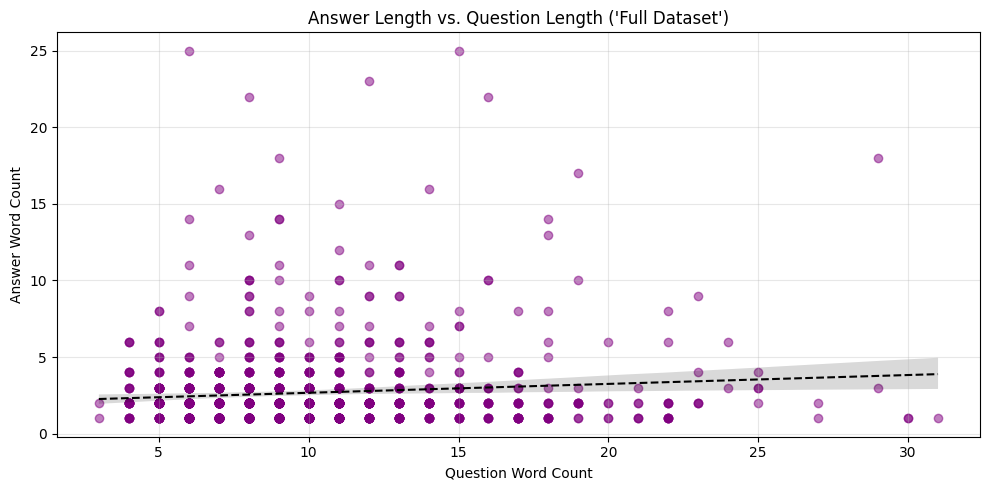

In [25]:
# Use the custom helper functions from the eda_scripts module:
# 1. Calculate r and p-values  
r_all, p_all = eda.calculate_correlation(question_lengths, answer_lengths)
# 2. Interpret the correlation and print results
corr_interpretation, r_strength = eda.interpret_correlation(r_all, p_all)
print(f"\nCorrelation between all question and answer lengths:\n"
      f"{'-'*70}\n"
      f"* r-value: {r_all:.2f}, p-value: {p_all:.3f}\n"
      f"* Interpretation: {corr_interpretation}\n"
      f"{'-'*70}\n")
# 3. Create a scatter plot of the correlation
eda.create_correlation_scatterplot(question_lengths, answer_lengths, "Full dataset" )

- There is a statistically significant (p: 0.002 < 0.05 ) relationship between the answer length and the question length. The null hypothesis can be rejected.
- The relationship is positive but weak (r = 0.094). This can be expected since the question length *alone* is not a strong predictor of the answer length.
- This is visually demonstrated in the scatter plot and its trend line. Most of the answers are short but there is a slight positive, linear relationship to the question length.
- More granular assessment could give an idea whether questions types can be predictive of the answer length.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 6: Keyword feature engineering

While analyzing length provides structural insights, a deeper assessment requires looking at the actual content. To systematically evaluate the dataset's topic diversity, context, and overall quality, we first need to process the raw text into a clean, usable format. This is accomplished using a custom tokenizer built with the nltk library.

### Custom tokenizer

The tokenizer was prototyped in this notebook and later modularized into a shared utility script for project-wide use. It performs a sequence of text processing steps to convert raw sentences into a list of meaningful root words. The main processing steps are:

1. **Clean and normalize**: First, the raw text is normalized by converting it to lowercase and removing all punctuation and numbers.
2. **Tokenize**: The cleaned string is then broken down into a list of individual word tokens.
3. **Filter**: To reduce noise, common English stopwords (like "the", "a", "in") and single-letter words are removed. Notably, a predefined list of interrogative keywords (e.g., "who", "what", "when") is excluded from this removal process to retain the core intent of the questions for analysis.
4. **Part-of-Speech (POS) Tagging**: Each filtered word is then assigned a grammatical tag (e.g., noun, verb, adjective) to identify its role in the sentence.
5. **Lemmatize**: Finally, using its POS tag for context, each word is converted to its base or dictionary form (e.g., "witches" becomes "witch," "flew" becomes "fly"). This ensures that different variations of the same word are treated as a single, consistent token.

The script for the custom tokenizer, named `tokenize_text` can be found here: [text processing utilities module](../src/ds_utils/text_processing.py)

>**Note on Iteration - Improved tokenizer**: 
>
>The process described here represents the initial version of the tokenizer. As the analysis will show later, this version of the tokenizer has a minor limitation in handling certain pronouns, which leads to a refined second version of the function in [section 7.3.5](#735-remaining-low-frequency-keywords). To maintain the workflow in the notebook, this older version has been moved to [obsolete_scripts.py](../src/ds_utils/obsolete_scripts.py). The obsolete tokenizer is referred to as `tokenize_text_v0_obsolete`.

### Creating token-based features

The tokenizer is utilized within a custom ([`create_token_columns`](../src/ds_utils/eda_scripts.py)) method to generate new columns containing lists of tokens. This process creates separate token lists for the question and answer fields, as well as a unified list combining tokens from both.

This approach serves two purposes: the individual token columns enable a distinct analysis of questions versus answers, whereas the combined column provides a holistic view of the entire interaction. These new features will be critical for downstream tasks, including hint generation and more sophisticated NLP modeling.

In [26]:
# create a copy of trivia_df
trivia_keywords_df = trivia_df.copy()

# Create unique 'keywords' column by tokenizing 'question', 'answer', and combined (question, answer) with the custom tokenizer using a custom method from eda_scripts
trivia_keywords_df = eda.create_token_columns(trivia_keywords_df, tokenizer=tokenize_text_v0_obsolete)

# Display the updated DataFrame
trivia_keywords_df.head()

,question,answer,question tokens,answer tokens,combined_unique_tokens
0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]"
1,When was Hogwarts founded?,10th century,"[when, hogwarts, found]","[10th, century]","[when, hogwarts, found, 10th, century]"
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, wronski, feint]","[pretend, dive, snitch]","[what, wronski, feint, pretend, dive, snitch]"
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[know, anything, name, method, make, broom, go, faster]","[use, polish]","[know, anything, name, method, make, broom, go, faster, use, polish]"
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate]","[14, sickle]","[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate, 14, sickle]"


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 7: EDA based on keywords

Now that the text data has been tokenized, we can perform an exploratory analysis based on the extracted keywords. This analysis aims to uncover the most common terms and themes across the dataset, providing insight into the core topics of the question-answer pairs. We'll begin by analyzing keyword frequency.

## 7.1: Overall keyword frequency

To understand which topics are most common, we will calculate the frequency of each keyword across the entire dataset. The goal is to count how many unique records a keyword appears in, rather than its total number of raw occurrences. This prevents a keyword that is repeated many times in a single answer from unfairly dominating the frequency count. The methodology is as follows:

1. **Utilize the unique keyword sets**: from the `combined_unique_keywords column`. This column distills the keywords for each record (question and answer pair) into a unique set. This prevents any single term from being over-counted and ensures a more accurate analysis of the topics present in each entry.
2. **Aggregate and count keywords**: Next, we use a single, chained command—.explode().value_counts()—to perform two actions at once:
    - `.explode()` aggregates the keywords by transforming the column of lists into one long column (a pandas Series) where each token is a separate row.
    - `.value_counts()` then counts the occurrences of each unique keyword in that new column. It groups the counts by keyword.
3. **Convert to dataframe**: Finally, the resulting `Counter` object is converted into a pandas DataFrame. This format simplifies sorting, filtering, and visualizing the keyword frequencies.

This will give us an overall keyword frequency count for the dataset.

In [27]:
# Create a series of all the unique tokens with their counts
all_tokens_counts = trivia_keywords_df['combined_unique_tokens'].explode().value_counts().reset_index()
# label the columns for clarity
all_tokens_counts.columns = ['token', 'count']
# add the percentage column
all_tokens_counts['percentage'] = ((all_tokens_counts['count'] / all_tokens_counts['count'].sum()) * 100).round(2)
# Sort the DataFrame by count in descending order
keyword_count_df = all_tokens_counts.sort_values(by='count', ascending=False).reset_index(drop=True)
# Display the top 10 most common tokens
print("Top 10 most common tokens:")
print("-"*30)
keyword_count_df.head(10)

Top 10 most common tokens:
------------------------------


,token,count,percentage
0,what,555,6.37
1,which,194,2.23
2,who,168,1.93
3,harry,144,1.65
4,name,118,1.35
5,hogwarts,89,1.02
6,do,82,0.94
7,how,70,0.80
8,use,65,0.75
9,where,65,0.75


In [28]:
# Filter the DataFrame to include only rows where count is greater than 20
frequency_cutoff = 20
filtered_keyword_count_df = keyword_count_df[keyword_count_df['count'] > 20]

print(f"There are {filtered_keyword_count_df.shape[0]} keywords with a frequency more then {frequency_cutoff}.")

There are 44 keywords with a frequency more then 20.


Visualizing the results as a bar chart will make the comparison a lot easier.

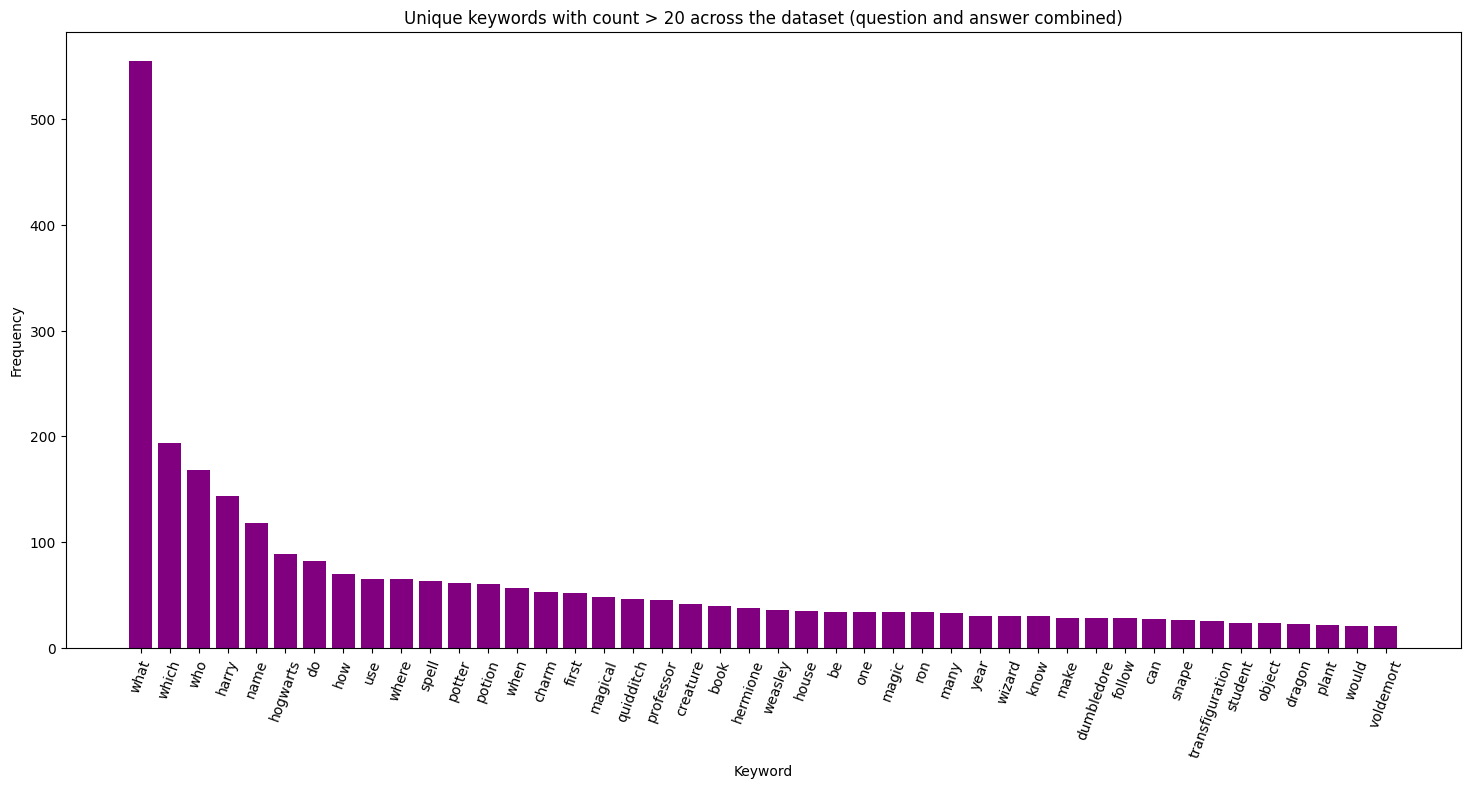

In [29]:
plt.figure(figsize=(18,8))

plt.bar(filtered_keyword_count_df['token'], filtered_keyword_count_df['count'], color="purple")

plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.title(f"Unique keywords with count > {frequency_cutoff} across the dataset (question and answer combined)")
plt.xticks(rotation=70)
plt.show()

The graph displays a long-tail distribution  which is common in text data (a [Zipfian distribution](https://medium.com/ai-enthusiast/zipfs-law-the-hidden-order-in-words-f6cf02e2cb86) where rank is inversely proportional to frequency). A small number of words appear very frequently, while the majority of words are rare. The most frequent terms are primarily common English words (stop words) and the central subjects of the dataset (the interrogative keywords that were purposefully kept). Some of the key insights from the distribution are:

1. **Prominent interrogative keywords**: The `what`, `which`, `who`, `name`, `how` and `where` tokens are in top 10 of the frequency counts, so it looks like majority questions are likely to be factual types. The prominence of `name` further supports this (e.g. "Name the spell...?").  These questions in all likelihood should have short answers. We can take a closer look at the dataset to confirm. `What` by far is the most common type of question keyword.
2. **Overlap with other grammatical use**: Tokens `be` (top) and `do` (third) appear very frequently because not only can they appear at the beginning of a question as an interrogative keyword (e.g. `is` or `did` respectively) but they are also used with the sentences as linking (copula) verbs. They are normally removed as stop words but were kept here to check if they could be used as interrogative keywords. Will look into it further into the EDA.
3. **Core topics and entities**: It's not a suprise that `harry` and `hogwarts` are also in the top - they would be the most common contextual keywords. Other frequent terms like `hermione`, `ron`, `weasley`, and `dumbledore` confirm the core subject matter is Harry Potter. Keywords like `spell`, `potion`, `charm`, `quidditch`, and `magic` are also very frequent. This could indicate a focus on specific, in-universe details.
4. **Evidence of different question types**: Tokens like `whats` and `would` also appear near the tail end of the graph. Keywords like `would` indicate that some questions could be quite open-ended. It would be interesting to look for similar words such as `why` and `how` for more open-ended type questions. Although `how` could also be factual, so a more versatile, hybrid type? If found, it would also mean that these types of questions are not very common since they don't show up in the graph (have a frequency count less than 20).

So going forward, the analysis should look for different questions, especially *factual-recall* types as well as *open-ended* and *multiple-choice*. The primary method to distinguish the question would be through the interrogative keyword (typically the first word in the question). Categorizing the question types can help understand the balance of the dataset and help in game play by being able to provide a variety of question types. For each interrogative keyword and/or question type we can look if there is a relationship between its question and answer length.  

For a deeper contextual understanding, we can also analyze frequent multi-word phrases (n-grams) and their relative importance using a TF-IDF n-gram analysis. The contextual keywords can also be classified using *customized NER (Named-Entity-Recognition) tags* that recognizes specific Harry Potter terms as *'spells', 'magical-locations', 'characters'*, etc. This will also allow for a contextual categorization allowing for a different layer of variety to the game sessions. The contextual labelling along with other features together can also help label difficulty of the questions.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 7.2: Factual recall questions

A cornerstone of any trivia game is the factual-recall question, designed to test a player's knowledge of specific facts like names, places, and events.
As the previous keyword analysis suggested, our dataset appears to be rich with these types of questions. The dominance of interrogative words like `what`, `which`, and `who` points directly to this format. To investigate further, we'll focus on identifying and analyzing questions that follow common factual patterns. These typically begin with keywords such as:
 - "Who...?" → Asks for a character.
 - "What...?" → Asks for an object, event, or fact.
 - "Where...?" → Asks for a location.
 - "When...?" or "In what year...?" → Asks for the timing of an event.
 - "How many...?" → Asks for a specific number (although 'how' on its own can be open-ended. so might have to check for presence of both)
 - "Name the..." → Asks for one or more specific names.

This section is quite lengthy, some quick link buttons for the subsections are provided here to help with navigating the notebook.

<div style="text-align: left;">
<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
<a href="#721-distribution-of-factual-recall-type-questions" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.2.1. Overall distribution</a>
<a href="#722-methodology-for-keyword-analysis" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.2.2. Methodology</a>
<a href="#723-what-do-the-what-questions-look-like" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.2.3. "What"</a>
<a href="#724-what-do-the-who-questions-look-like" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.2.4. "Who"</a>
<a href="#725-what-do-the-where-questions-look-like" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.2.5. "Where"</a>
<a href="#726-what-do-when-questions-look-like" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.2.6. "When"</a>
</div>

### 7.2.1: Distribution of factual recall type questions 

To get a high-level view of the dataset, we first need to look at the distribution of different factual-recall question types and determine which ones are most common. 

First, a curated list of factual-recall keywords was developed based on keyword frequency plot earlier and was updated iteratively throughout the analysis as new terms were discovered. Next, a new feature column, factual_recall_keyword, was engineered to categorize each question. A custom method (`eda.tag_questions_by_keyword_list()`) was used to identify all interrogative keywords in a question. The `get_main_keyword` was then used identify the main interrogative keyword by identifying the first keyword 'factual_recall' column and assign it as the category for that row. This new feature column provides a straightforward way to filter the entire dataset, allowing for analysis of the prevalence of each distinct factual-recall question type.

> **Note on iteration (v0.1) - Improved `main_keyword` tagging**: 
>
>The initial version of the `get_main_keyword` function had a key limitation: it often failed to distinguish between primary interrogative pronouns (like 'what', 'where') and auxiliary verbs (like 'be'), which blurred the analysis of non-factual questions. This was resolved by implementing a precedence rule that correctly prioritizes the interrogative pronoun when both types of keywords are present.To demonstrate this improvement, the notebook will first use the original, flawed function, which is referred to as get_main_keyword_v0_obsolete. The full discussion and transition to the improved method occurs in [section 7.3](#73-questions-that-do-not-have-factual-recall-keywords).
>
>For code cleanliness, the obsolete version is stored separately in [obsolete_scripts.py](../src/ds_utils/obsolete_scripts.py), while the final, correct version resides in the main [eda_scripts.py module](../src/ds_utils/eda_scripts.py).
>

In [30]:
# list of words to look for when identifying 'factual recall' questions 
factual_recall_list = ['what', 'name', 'who', 'where', 'when']
# This method returns a list of any of the keywords that are present in the 'question tokens' column in order of appearance.
trivia_keywords_df = eda.tag_questions_by_keyword_list(
    df=trivia_keywords_df,
    keyword_column='question tokens', # Make sure this is the correct column name
    trigger_keyword_list=factual_recall_list,
    new_column_name='factual_recall_keyword'
)
# Main interrogative keyword ()
trivia_keywords_df['main_keyword'] = trivia_keywords_df['factual_recall_keyword'].apply(obs.get_main_keyword_v0_obsolete)
# Sanity check
trivia_keywords_df.sample(5, random_state=16)

,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,main_keyword
169,How is the Grey Lady related to Rowena Ravenclaw?,She's Rowena's daughter.,"[how, grey, lady, relate, rowena, ravenclaw]","[rowena, daughter]","[how, grey, lady, relate, rowena, ravenclaw, daughter]",[],unassigned
467,Where is Ovomancy thought to originate?,Ancient Greece,"[where, ovomancy, think, originate]","[ancient, greece]","[where, ovomancy, think, originate, ancient, greece]",[where],where
270,What magical plant allows humans to breathe underwater?,Gillyweed,"[what, magical, plant, allows, humans, breathe, underwater]",[gillyweed],"[what, magical, plant, allows, humans, breathe, underwater, gillyweed]",[what],what
593,Which statement is true about conjured objects?,They vanish in time,"[which, statement, true, conjure, object]","[vanish, time]","[which, statement, true, conjure, object, vanish, time]",[],unassigned
244,What did Hagrid name his pet dragon?,Norbert,"[what, hagrid, name, pet, dragon]",[norbert],"[what, hagrid, name, pet, dragon, norbert]","[what, name]",what


From the dataframe samples, the `factual_recall_keyword` column can have a single, multiple, or no keywords assigned. The custom method used to extract the keywords ensures that the words are captured in order of appearance within the question. We can see that some questions (Q.244. **What** did Hagrid **name** his pet dragon?)) can have multiple keywords. This could be because of grammatical structure where the first keyword is the main interrogative keyword. But it can also be becasue of multiple questions being asked in the same instance.

In [31]:
# sample of questions with multiple fr keywords:
has_multiple_fr_keywords = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword'].str.len()>1]
print(f"There are {has_multiple_fr_keywords.shape[0]} questions with multiple factual recall keywords assigned to them.\n")
print("Sample of questions with multiple factual recall keywords:")
has_multiple_fr_keywords.sample(5, random_state=16)

There are 139 questions with multiple factual recall keywords assigned to them.

Sample of questions with multiple factual recall keywords:


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,main_keyword
1033,Voldemort stole Helga Hufflepuff's cup from an old woman named Hepzibah Smith. What was the name of her house-elf?,Hokey,"[voldemort, steal, helga, hufflepuff, cup, old, woman, name, hepzibah, smith, what, house, elf]",[hokey],"[voldemort, steal, helga, hufflepuff, cup, old, woman, name, hepzibah, smith, what, house, elf, hokey]","[name, what]",name
734,What were the wizards who cooperated with the Muggles called?,Scourers.,"[what, wizard, who, cooperate, muggles, call]",[scourer],"[what, wizard, who, cooperate, muggles, call, scourer]","[what, who]",what
244,What did Hagrid name his pet dragon?,Norbert,"[what, hagrid, name, pet, dragon]",[norbert],"[what, hagrid, name, pet, dragon, norbert]","[what, name]",what
447,What is the name of the Hogwarts poltergeist?,Peeves,"[what, name, hogwarts, poltergeist]",[peeve],"[what, name, hogwarts, poltergeist, peeve]","[what, name]",what
599,What is the name of Hagrid's pet dragon?,Norbert,"[what, name, hagrid, pet, dragon]",[norbert],"[what, name, hagrid, pet, dragon, norbert]","[what, name]",what


There are 139 questions with more than one factual-recall keyword within it, not a significant portion. Q. 1033 (*"Voldemort stole Helga Hufflepuff's cup from an old woman named Hepzibah Smith. What was the name of her house-elf?"*) is an instance where there are multiple sentences. The first sentence providing context to the following question. But there could be instances where both are questions. 

In [32]:
# Using regex to find questions with multiple sentences or multiple questions
pattern1 = r'[.!]..*\?'  # sentence followed by a question
pattern2 = r'[?]..*\?'   # two questions

# Get the count based on the regex patterns
num_multiple_sentences = trivia_keywords_df['question'].str.contains(pattern1, regex=True).sum()
num_multiple_questions = trivia_keywords_df['question'].str.contains(pattern2, regex=True).sum()
# print results
print(f"There are {num_multiple_sentences} questions with multiple sentences in the same instance.")
print(f"There are {num_multiple_questions} question records with multiple questions in the same instance.")
# view sample df
multi_sentence_questions = trivia_keywords_df[trivia_keywords_df['question'].str.contains(pattern1, regex=True)]
display(multi_sentence_questions.head())

There are 44 questions with multiple sentences in the same instance.
There are 0 question records with multiple questions in the same instance.


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,main_keyword
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate]","[14, sickle]","[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate, 14, sickle]",[],unassigned
16,Cedric Diggory let Harry use the prefect's bathroom in The Goblet of Fire. What man's statue is next to the special lavatory entrance?,Boris the Bewildered.,"[cedric, diggory, let, harry, use, prefect, bathroom, goblet, fire, what, man, statue, next, special, lavatory, entrance]","[boris, bewilder]","[cedric, diggory, let, harry, use, prefect, bathroom, goblet, fire, what, man, statue, next, special, lavatory, entrance, boris, bewilder]",[what],what
53,"In the book, which old friend do Harry, Ron and Hermione run into at St. Mungo’s Hospital for Magical Maladies and Injuries?",Gilderoy Lockhart,"[book, which, old, friend, do, harry, ron, hermione, run, st, mungo, hospital, magical, malady, injury]","[gilderoy, lockhart]","[book, which, old, friend, do, harry, ron, hermione, run, st, mungo, hospital, magical, malady, injury, gilderoy, lockhart]",[],unassigned
72,Ginny Weasley bought a pet Pygmy Puff from her older brothers' joke shop. What did she name it?,Arnold,"[ginny, weasley, buy, pet, pygmy, puff, old, brother, joke, shop, what, name]",[arnold],"[ginny, weasley, buy, pet, pygmy, puff, old, brother, joke, shop, what, name, arnold]","[what, name]",what
74,I'd be surprised if you knew this. what's the first step of flying on your broom?,Kicking off,"[be, surprise, know, what, first, step, fly, broom]",[kick],"[be, surprise, know, what, first, step, fly, broom, kick]",[what],what


The analysis here found no instances where a single record contained two distinct questions (e.g., two question marks). While the dataset contains 139 records with multiple interrogative keywords, only 44 of those are multi-sentence questions. A review of this subset confirmed that none were structured as two separate questions.

Although this check isn't exhaustive, other variations such as two questions joined by "and," could exist. The findings confirm this is not a widespread issue. We can therefore proceed with the EDA, confident that it won't significantly impact the results. Any remaining edge cases can be addressed during the final data quality review.

Now let's look at the distribution of factual versus non-factual questions:

In [33]:
## How many of the records have not been tagged factual recall questions?

# Questions that are not-factual recall types
condition1 = (trivia_keywords_df['main_keyword']=='unassigned')
condition2 = (trivia_keywords_df['main_keyword']=='other')
not_factual_q_count = trivia_keywords_df.loc[condition1|condition2]['question'].count()
other_type = trivia_keywords_df[trivia_keywords_df['main_keyword']=='other']['question'].count()
not_factual_q_percentage = (not_factual_q_count / trivia_keywords_df.shape[0]) * 100
# where 'factual_recall_keyword' is not N/A
factual_q_count = trivia_keywords_df.shape[0] - not_factual_q_count
factual_q_percentage = 100 - not_factual_q_percentage

# display results
print("Factual recall questions:\n",
      f"- There are at least {factual_q_count} questions ({factual_q_percentage: .0f}% of total count) that can be considered factual recall types.\n",
      f"- There are {not_factual_q_count} questions ({not_factual_q_percentage: .0f}% of total count) that can be considered as not being factual recall types.\n",
      f"- {other_type} quesstions were uncategorized and marked as 'other' type questions.\n"
)

Factual recall questions:
 - There are at least 805 questions ( 74% of total count) that can be considered factual recall types.
 - There are 280 questions ( 26% of total count) that can be considered as not being factual recall types.
 - 0 quesstions were uncategorized and marked as 'other' type questions.



As expected, most of the dataset leans heavily toward factual-recall questions—about 74% in total. The rest fall into the non-factual category. To get a clearer picture of these factual questions, we’ll explore them in two ways:

1. **Overall keyword frequency**: First, we'll plot the frequency of every interrogative keyword from the `factual_recall_keyword` lists. This shows the raw prevalence of all keywords and highlights how often they occur together within the same question.

2. **Primary keyword distribution**: Next, we'll plot the distribution of only the single, main interrogative keyword for each question. This more clearly shows which specific question formats are most common.

#### Overall keyword frequency plot

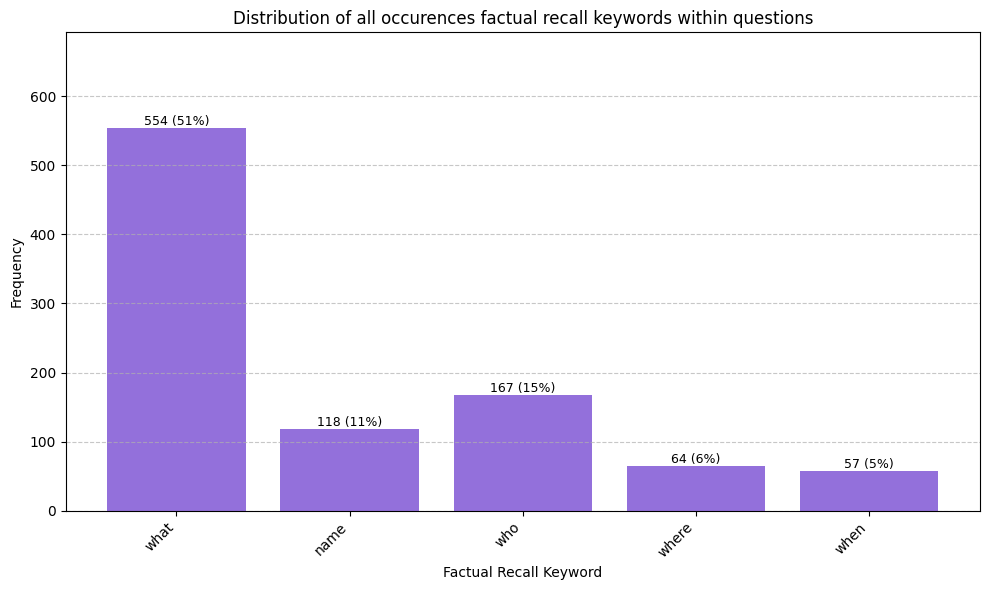

In [34]:
## How are the factual questions distributed?
# 1. Create a dictionary to store values for easy plotting
factq_dict = {}
total = trivia_keywords_df.shape[0]

# for getting keyword counts and percentages that can be uesd for plotting
for keyword in factual_recall_list:
    # check if keyword contains a list and then if keyword is in the list:
    filter_condition = lambda x: keyword in x if isinstance(x, list) else False
    count = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword'].apply(filter_condition)].shape[0]
    factq_dict[keyword] = {
        'count': count,
        'percentage of total': (count / total) * 100}

# 2. Visualize as a barchart  using custom method from eda_scripts
factq_counts_series = pd.Series({k: v['count'] for k, v in factq_dict.items()})
total_questions = trivia_keywords_df.shape[0]

eda.plot_categorical_distribution(factq_counts_series, total_questions,
                              "Distribution of all occurences factual recall keywords within questions",
                              "Factual Recall Keyword")   

#### Primary keyword distribution plot

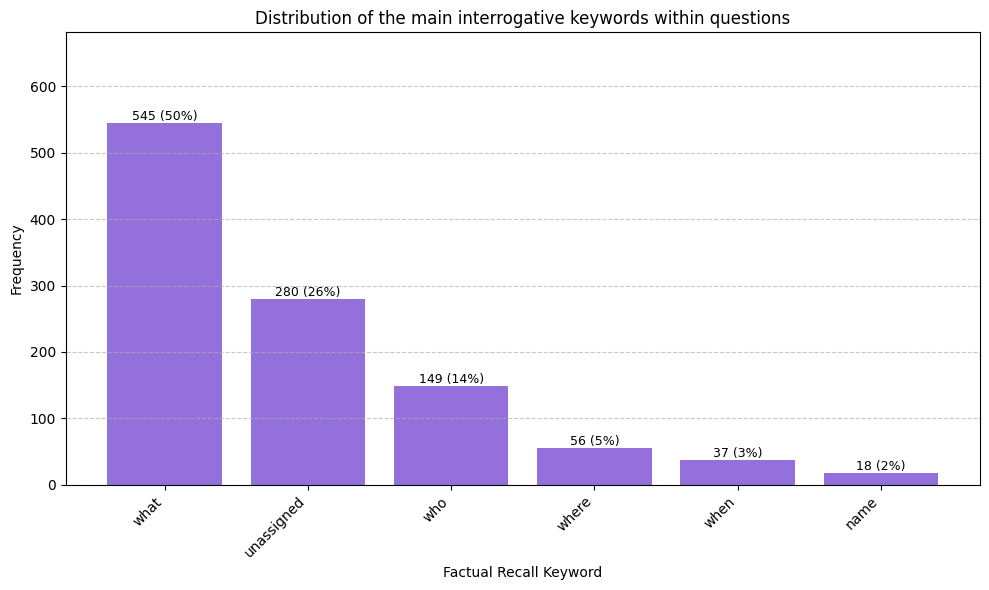

In [35]:
total_questions = trivia_keywords_df.shape[0]
main_fr_keyword_counts = trivia_keywords_df['main_keyword'].value_counts()
eda.plot_categorical_distribution(main_fr_keyword_counts, total_questions,
                              "Distribution of the main interrogative keywords within questions",
                              "Factual Recall Keyword")

The plots confirm that `what` questions are the most common, making up nearly half of all factual-recall questions in the dataset. 

When we compare the total number of times a keyword appears to how often it’s the primary keyword, an interesting pattern shows up. For example, while the keyword `name` appears in 11% of all questions, it is the main interrogative word in only 2% of them. This indicates that `name` is most often used as a supporting term within other question types (e.g., "What did Hagrid name his pet dragon?"). Similarly, the frequency of `when` is nearly halved when filtered for its role as the primary keyword.With this in mind, the `main_fr_keyword` column will be used as the key feature for categorizing questions, since it more accurately reflects the question's primary intent.

Also, based on these findings we can start thinking about guidelines for standardizing the dataset and any new additions. For consistency, each question should be a single, clear, unambiguous query and make sure its main interrogative keyword is right at the start.

We can now methodically analyze each of the main factual recall keywords further.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#72-factual-recall-questions" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.2 Quick Links</a>

### 7.2.2: Methodology for keyword analysis:
A set of custom methods were developed to explore these questions systematically (located in the [eda_scripts.py](../src/ds_utils/eda_scripts.py) module. This creates a standardized and efficient workflow for analyzing each question type. To investigate a given interrogative keyword, the process involves three main steps:

1. **Get a Statistical Overview**: The `eda.get_question_type_info()` function provides a high-level summary for a given keyword (e.g., "what"). It filters the dataset for relevant records and calculates key statistics, including:
 - The total count and percentage of questions containing the keyword.
 - Descriptive statistics (min, max, mean) for the corresponding question and answer lengths.
 - A random sample of the questions for a qualitative check.
2. **Visualize the question and answer lengths**: The `eda.create_ans_len_boxplot()` function generates a box plot to visually compare the answer lengths of a specific question type against the rest of the dataset. This is a quick way to test our hypothesis that factual-recall questions have shorter, more concise answers.
3. **Analyze common phrases (N-grams)**: Finally, `eda.print_keyword_ngrams()` helps us understand the context by extracting the most common phrases (n-grams) associated with a keyword. By looking at frequent word sequences (e.g., "what is the name" or "how many horcruxes"), we can confirm the question's structure and the specific topics being asked.

The main analysis parameters going forward are defined here for ease of use and error management. This includes:
- `df_for_analysis`: The cleaned and processed copy of the dataset that is the same across the analysis but called multiple times in functions.
- `n_samples`: The number of random samples to display from the dataframe filtered by keyword (the methods have built-in corrections if the dataframe size is smaller then n_samples).

In [36]:
# Parameters for analysis:
df_for_analysis = trivia_keywords_df.reset_index(names='original_question_id').copy()  # using a copy to keep the original intact and keep the original question id as a column
n_samples = 5
df_for_analysis.head()

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,main_keyword
0,0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]",[what],what
1,1,When was Hogwarts founded?,10th century,"[when, hogwarts, found]","[10th, century]","[when, hogwarts, found, 10th, century]",[when],when
2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, wronski, feint]","[pretend, dive, snitch]","[what, wronski, feint, pretend, dive, snitch]",[what],what
3,3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[know, anything, name, method, make, broom, go, faster]","[use, polish]","[know, anything, name, method, make, broom, go, faster, use, polish]",[name],name
4,4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate]","[14, sickle]","[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate, 14, sickle]",[],unassigned



### 7.2.3: What do the `"what"` questions look like?
Let's start by looking at "What" type questions as they are the most common (49% of the questions).

## Analysis for Keyword: 'WHAT'

Number of Questions: 545 (50.2% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,10.01,2.54
Median,9.00,2.00
Std Dev,4.54,2.35
Min,3.00,1.00
Max,30.00,22.00
Skew,1.52,3.57



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.081)
* Pearson's r = 0.081, P-value = 0.058

Scatter Plot with Regression Line:


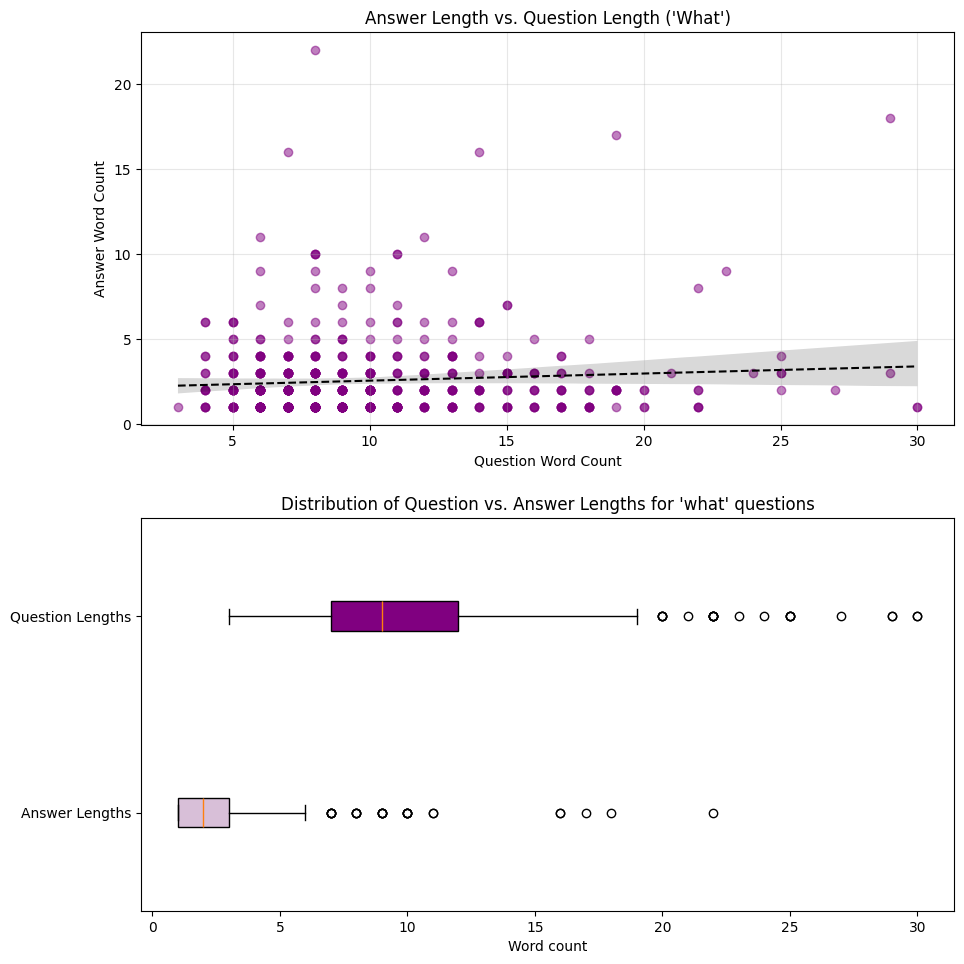


Random Sample (5) of 'what' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,main_keyword
931,931,What does Professor Vector Teach?,Arithmancy.,"[what, professor, vector, teach]",[arithmancy],"[what, professor, vector, teach, arithmancy]",[what],what
498,498,What tail did Hagrid make Dudley grow because the Dursleys were rude?,Pig tail,"[what, tail, hagrid, make, dudley, grow, dursleys, rude]","[pig, tail]","[what, tail, hagrid, make, dudley, grow, dursleys, rude, pig]",[what],what
280,280,"Monkshood and wolfsbane are the same plant, also known as what?",Aconite,"[monkshood, wolfsbane, plant, also, know, what]",[aconite],"[monkshood, wolfsbane, plant, also, know, what, aconite]",[what],what
622,622,What is another name for the Alihotsy tree?,The hyena tree.,"[what, another, name, alihotsy, tree]","[hyena, tree]","[what, another, name, alihotsy, tree, hyena]","[what, name]",what
827,827,What is Harry's middle name?,James,"[what, harry, middle, name]",[james],"[what, harry, middle, name, james]","[what, name]",what


----------------------------------------------------------------------


In [37]:
q_keyword = "what"
what_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(what_q_metrics, n_samples)

In [38]:
eda.print_keyword_ngrams(df_for_analysis['question'],'what',(2,5))


Analyzing common phrases (n-grams) starting with 'what' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'what':
- 'what is': 174
- 'what is the': 111
- 'what does': 50
- 'what is the name': 46
- 'what is the name of': 46
- 'what was': 27
- 'what did': 24
- 'what does the': 21
- 'what was the': 18
- 'what are': 17


In [39]:
# let's remove 'is', 'the', 'are', 'was' as our custom stop word list:
stop_words = ['is', 'the', 'are', 'was', 'does', 'did', 'do', 'kind', 'of', 'for','type'] 
eda.print_keyword_ngrams(df_for_analysis['question'],'what',(2,5), 10, stop_words)


Analyzing common phrases (n-grams) starting with 'what' in this set of questions:
Using stop_words: ['is', 'the', 'are', 'was', 'does', 'did', 'do', 'kind', 'of', 'for', 'type']
Top 10 common n-grams starting with 'what':
- 'what name': 63
- 'what spell': 17
- 'what magical': 16
- 'what creature': 15
- 'what incantation': 13
- 'what harry': 10
- 'what potion': 9
- 'what magical creature': 8
- 'what animal': 6
- 'what charm': 6


#### Analysis of "What" Questions results
The "what" questions form the largest category of factual-recall queries in the dataset. A closer look reveals several key characteristics:

1. **Answers are consistently short**: While the question lengths can vary significantly (from 3 to 30 words), the answers are consistently brief. The median answer length is just 2 words, with an interquartile range (IQR) of 1 to 3 words. This strongly supports the hypothesis that these are direct, factual questions requiring concise answers.
2. **No Correlation Between Question and Answer Length**: A statistical analysis found no meaningful correlation between the length of a "what" question and the length of its answer. This makes intuitive sense; a longer, more detailed question doesn't necessarily require a longer answer when it's asking for a single, specific fact (like a name or place).
3. **The N-grams confirm factual nature**: A qualitative review of sample questions suggested they were factual, and an n-gram analysis confirms this quantitatively. The most common phrases at the beginning of these questions are:
    - "What name..."
    - "What spell..."
    - "What magical..."

These n-grams show a clear pattern of asking for specific nouns—names, spells, and magical objects, further confirming that these questions are straightforward, factual queries. As a next step, we can take an even closer look at questions where "name" is the key interrogative word.

In [40]:
## What do questions with the 'name' keyword look like?

# Filter question that the word 'name' in them
name_questions = df_for_analysis.loc[df_for_analysis['question tokens'].apply(lambda x: keyword in x)]

# Now filter that subset of question to find the occurence of "name" without "what" / "what's" present.
name_nowhat_questions = name_questions[
    ~name_questions['question tokens'].apply(lambda x: 'what' in x or 'whats' in x)
]
# display results
print("Occurence of 'name' without 'what' in the trivia questions: ",name_nowhat_questions.shape[0])

Occurence of 'name' without 'what' in the trivia questions:  38


It look like that in this dataset "name" always appears with "what". So we don't have to consider them separately for now. However, it is entirely possible to phrase the question with just "name", e.g. *"Name the characters from ....."* and can be possible when the dataset is expanded.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#72-factual-recall-questions" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.2 Quick Links</a>

### 7.2.4: What do the `"who"` questions look like?
The second most frequent FR keyword is "who" (15% of all questions). Such questions will likely ask about specific details about a person.

## Analysis for Keyword: 'WHO'

Number of Questions: 149 (13.7% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,8.77,2.56
Median,8.00,2.00
Std Dev,3.98,1.86
Min,3.00,1.00
Max,31.00,11.00
Skew,1.99,3.30



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.135)
* Pearson's r = 0.135, P-value = 0.102

Scatter Plot with Regression Line:


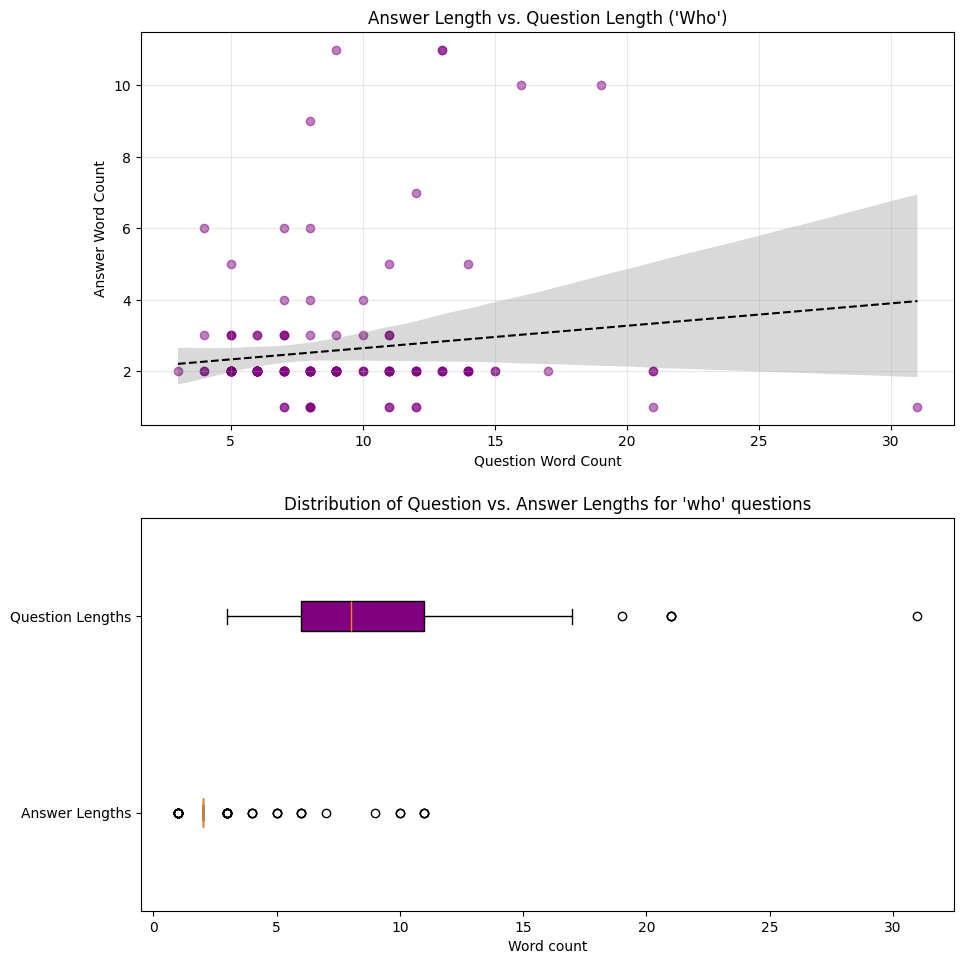


Random Sample (5) of 'who' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,main_keyword
681,681,Who is the second Peverell brother?,Cadmus Peverell,"[who, second, peverell, brother]","[cadmus, peverell]","[who, second, peverell, brother, cadmus]",[who],who
141,141,Who was the Rook in the Chessboard Chamber?,Hermione Granger,"[who, rook, chessboard, chamber]","[hermione, granger]","[who, rook, chessboard, chamber, hermione, granger]",[who],who
517,517,Who is the Slytherin ghost?,The Bloody Baron,"[who, slytherin, ghost]","[bloody, baron]","[who, slytherin, ghost, bloody, baron]",[who],who
554,554,Who is the giant three-headed dog that guards the trapdoor leading to the Philosopher's Stone in the first book?,Fluffy,"[who, giant, three, head, dog, guard, trapdoor, lead, philosopher, stone, first, book]",[fluffy],"[who, giant, three, head, dog, guard, trapdoor, lead, philosopher, stone, first, book, fluffy]",[who],who
987,987,Who plays Professor Dumbledore in this and the subsequent Harry Potter movies?,Michael Gambon,"[who, play, professor, dumbledore, subsequent, harry, potter, movie]","[michael, gambon]","[who, play, professor, dumbledore, subsequent, harry, potter, movie, michael, gambon]",[who],who


----------------------------------------------------------------------


In [41]:
q_keyword = "who"
who_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(who_q_metrics, n_samples)

**Note**: Although we know there is considerable overlap between 'what' and 'name' - 'name' remains in assessment for completeness.

In [42]:
# With no stop_words considered:
eda.print_keyword_ngrams(df_for_analysis['question'],"who", (2,5))


Analyzing common phrases (n-grams) starting with 'who' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'who':
- 'who is': 56
- 'who is the': 38
- 'who was': 20
- 'who was the': 12
- 'who wrote': 8
- 'who does': 7
- 'who invented': 5
- 'who is harry': 4
- 'who teaches': 4
- 'who created': 3


In [43]:
# Using a custom list of stop words.
stop_words = ['is', 'was', 'does', 'the', 'of', 'in']
eda.print_keyword_ngrams(df_for_analysis['question'],"who", (3,7), stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'who' in this set of questions:
Using stop_words: ['is', 'was', 'does', 'the', 'of', 'in']
Top 10 common n-grams starting with 'who':
- 'who headmaster hogwarts': 6
- 'who harry potter': 3
- 'who harry potter godfather': 3
- 'who original owner': 3
- 'who created sorcerer': 2
- 'who created sorcerer stone': 2
- 'who destroyed horcrux': 2
- 'who destroyed horcrux helga': 2
- 'who divination professor': 2
- 'who flying instructor': 2


#### Analysis of "who" questions
Questions beginning with "who" are designed to identify specific characters. The analysis shows they have a distinct and highly consistent profile.
1. **Exceptionally concise answers**: While question lengths vary similarly to other categories (ranging from 3 to 31 words), the answers to "who" questions are even more concise than those for "what" questions. With a median of 2 words and a negligible Interquartile Range (IQR), the answers are consistently very short, often just a first and last name.
2. **No correlation between question and answer lengths**: As with "what" questions, there is no statistical relationship observed between the length of a "who" question and its answer. The direct nature of these questions means even a long, context-rich question is typically answered with just a name.
3. **The N-grams confirm focus on character identities**: Both sample reviews and n-gram analysis confirm that these questions focus on identifying characters based on their roles or actions. The most common n-gram, "Who headmaster hogwarts", is a prime example.
    - This specific phrase suggests that several questions might be asking about who the headmaster is at different times or it could mean there are some (semantic) duplicates that were missed.
    - The few longer answers are typically questions that for a list of names rather than for a single person.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#72-factual-recall-questions" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.2 Quick Links</a>

### 7.2.5: What do the "where" questions look like? 
The *"where"* questions account for only 6% of the dataset. These questions would ask to name a place based on where certain book facts and events occured. 

## Analysis for Keyword: 'WHERE'

Number of Questions: 56 (5.2% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,8.89,3.29
Median,9.00,3.00
Std Dev,3.72,2.51
Min,4.00,1.00
Max,22.00,14.00
Skew,1.16,2.39



Correlation between Question and Answer Length:
* Interpretation: Statistically significant (correlation is Weak)
* Pearson's r = 0.316, P-value = 0.018

Scatter Plot with Regression Line:


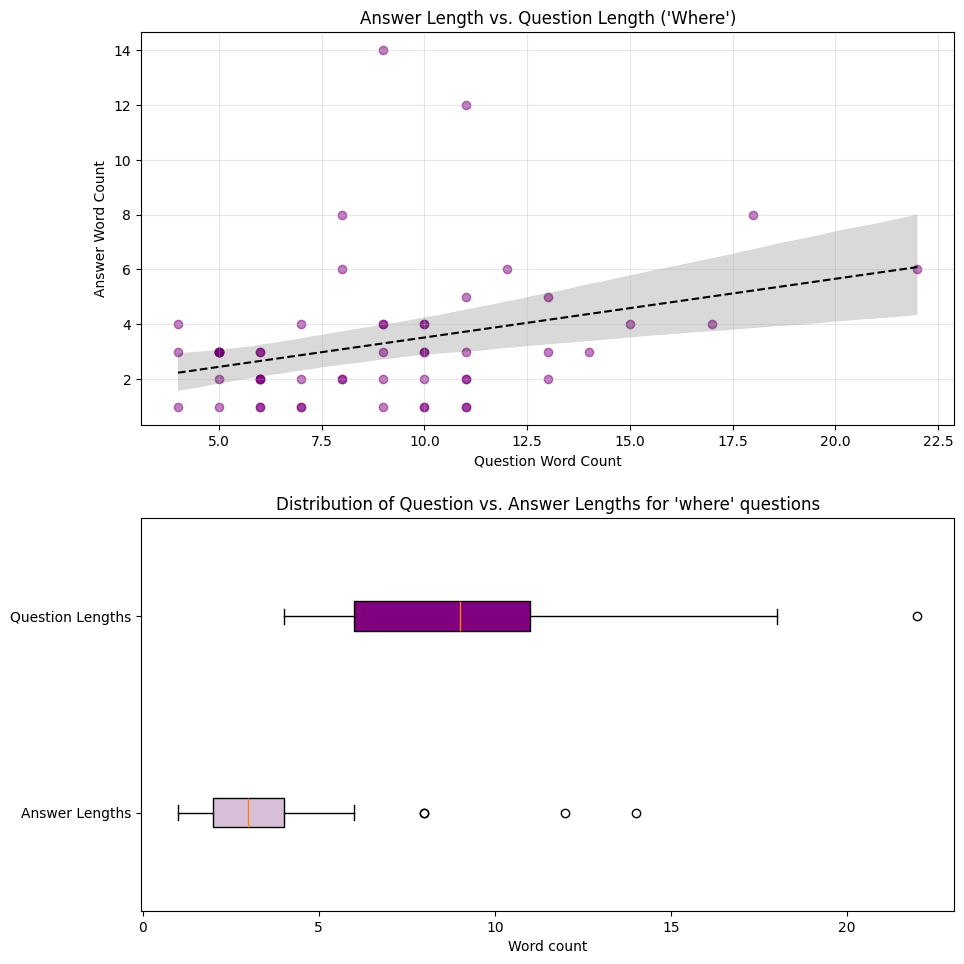


Random Sample (5) of 'where' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,main_keyword
366,366,Where are the vaults kept in Gringotts Bank?,Deep underground.,"[where, vault, keep, gringotts, bank]","[deep, underground]","[where, vault, keep, gringotts, bank, deep, underground]",[where],where
65,65,Where can dark cloud constellations be most easily seen?,The Southern Hemisphere.,"[where, can, dark, cloud, constellation, be, easily, see]","[southern, hemisphere]","[where, can, dark, cloud, constellation, be, easily, see, southern, hemisphere]",[where],where
777,777,Where did Emeric the Evil spend most of his life?,England,"[where, emeric, evil, spend, life]",[england],"[where, emeric, evil, spend, life, england]",[where],where
630,630,Where do monks grow gravity-resistant trees?,Nepal,"[where, do, monk, grow, gravity, resistant, tree]",[nepal],"[where, do, monk, grow, gravity, resistant, tree, nepal]",[where],where
690,690,Where do vanished items go?,Into non-being,"[where, do, vanish, item, go]",[non],"[where, do, vanish, item, go, non]",[where],where


----------------------------------------------------------------------


In [44]:
q_keyword = "where"
where_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(where_q_metrics, n_samples)

In [45]:
eda.print_keyword_ngrams(df_for_analysis['question'], "where")


Analyzing common phrases (n-grams) starting with 'where' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'where':
- 'where is': 14
- 'where is the': 12
- 'where did': 9
- 'where do': 8
- 'where does': 8
- 'where was': 5
- 'where are': 4
- 'where can': 3
- 'where was harry': 3
- 'where are the': 2


In [46]:
# Using a custom list of stop words.
stop_words = ['is', 'did', 'do', 'does', 'was', 'are', 'can', 'the', 'to']
eda.print_keyword_ngrams(df_for_analysis['question'], "where",stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'where' in this set of questions:
Using stop_words: ['is', 'did', 'do', 'does', 'was', 'are', 'can', 'the', 'to']
Top 10 common n-grams starting with 'where':
- 'where harry': 8
- 'where harry potter': 5
- 'where entrance': 4
- 'where entrance chamber': 3
- 'where best': 2
- 'where best place': 2
- 'where dumbledore': 2
- 'where find': 2
- 'where find them': 2
- 'where first': 2


#### Analysis of "where" questions:
1. **Answers again are short**: The answers are still quite short, with a median length of 3 words. However, they show more variability than "who" or "what" questions, with some answers being as long as 14 words and fewer outliers.  This variation likely reflects the difference between answering with a simple place name versus a more descriptive location.

2. **Weak correlation**: Unlike other keywords, the "where" questions show a different statistical pattern.  The analysis reveals a weak but statistically significant positive correlation between question and answer length (p=0.018, r=0.316). The scatter plot visually supports this trend, and the box plot confirms that answers to "where" questions have a wider distribution (median of 3 words, but a range up to 14) than other factual types. This suggests that longer "where" questions tend to elicit longer answers. This could be because:
    - While some questions elicit a strightforward answer (e.g. "Godric's hollow"), other answers need to more descriptive (e.g. "in the room of requirement"). 
    - More complex questions require more specific, longer answers (e.g full location names like "Number 12 Grimmauld Place").
    - The "where" term can also be ambiguous (referring to room, building, village, or country). So a longer question might provide more context to pinpoint a location, which in turn requires a more detailed answer (e.g. "Gryffindor common room" rather than just "Hogwarts".)

    We should take this finding with a grain of salt. It’s based on a pretty small sample with just 56 questions (5% of the dataset). With smaller samples, outliers can have a larger influence on the overall correlation. So eventhough the p-value suggests the trend isn’t random, the limited sample size means we should be careful about generalizing this finding too broadly.

3. **N-grams and data quality insights**: After filtering out common stop words, the n-gram analysis confirms that the questions are factual and focused on specific characters and places. The most common phrases include *"where harry", "where harry potter"*, and *"where entrance chamber"*. The counts also show natural overlaps; for instance, of the 8 bigrams for "where harry", 5 are part of the more specific trigram "where harry potter," giving us a granular view of the question subjects. The samples and N-grams also highlighted data quality issues that will need to be addressed and is critical for gaming experience:
    - *Out of scope*: One question about astronomy is unrelated to Harry Potter ("Q65. Where can dark cloud constellations be most easily seen? Southern Hemisphere"). Other similar questions might be present.
    - *Incorrect questions*: A question in the samples does not seem to be correct as per Harry Potter lore ("Q480. Where do I- I mean, where does Tonks like to hide Jelly Slugs? Herbology Pots"). This seems to be from a questionable source (e.g. fan fiction?).

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#72-factual-recall-questions" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.2 Quick Links</a>

### 7.2.6: What do "when" questions look like?
In questions when *"when"* is the initial interrogative keyword, it typically would be asking about time related events. 

## Analysis for Keyword: 'WHEN'

Number of Questions: 37 (3.4% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,10.35,2.51
Median,9.00,2.00
Std Dev,5.99,2.34
Min,4.00,1.00
Max,27.00,13.00
Skew,1.14,2.91



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.169)
* Pearson's r = 0.169, P-value = 0.317

Scatter Plot with Regression Line:


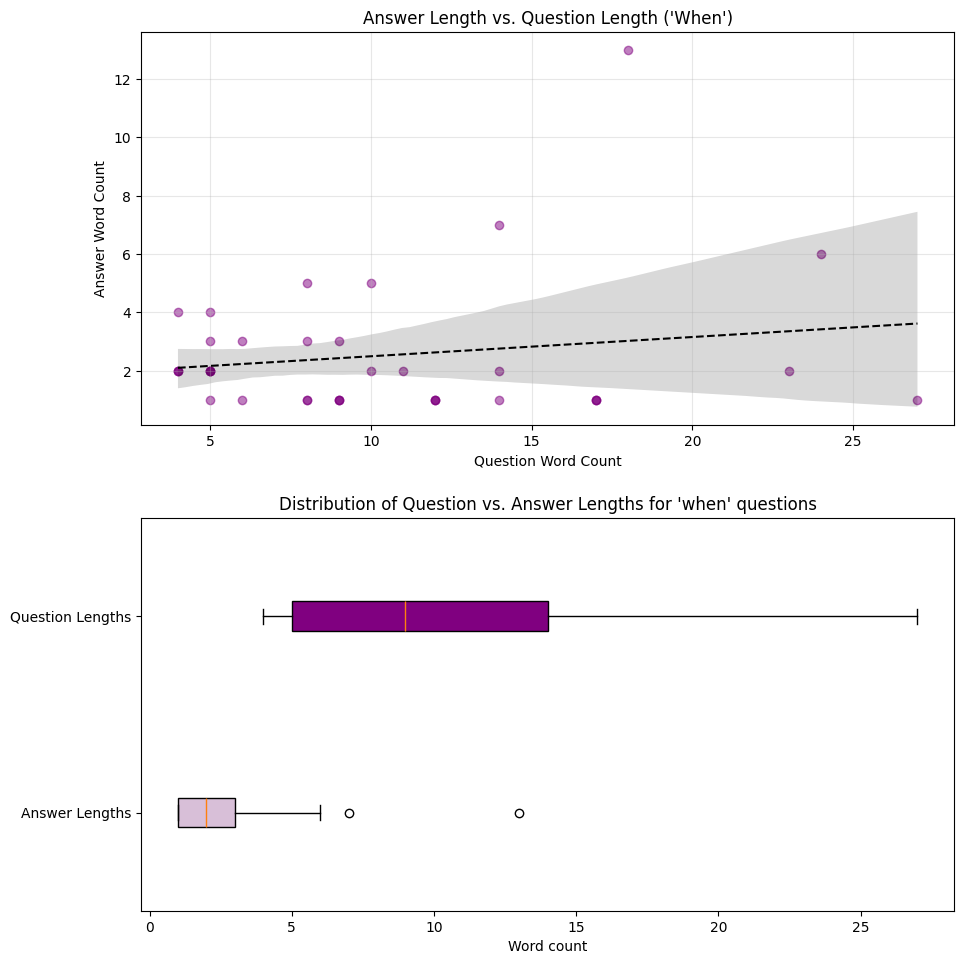


Random Sample (5) of 'when' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,main_keyword
245,245,"When practising Bibliomancy, what passage should one select?",A random passage,"[when, practise, bibliomancy, what, passage, should, one, select]","[random, passage]","[when, practise, bibliomancy, what, passage, should, one, select, random]","[when, what]",when
883,883,Does Blue Sparks do any damage when cast on people?,It only hurts a little.,"[blue, spark, do, damage, when, cast, people]","[hurt, little]","[blue, spark, do, damage, when, cast, people, hurt, little]",[when],when
657,657,When was He Who Must Not Be Named defeated?,Halloween,"[when, who, must, be, name, defeated]",[halloween],"[when, who, must, be, name, defeated, halloween]","[when, who, name]",when
656,656,When was Ollivanders founded?,382 BC,"[when, ollivanders, found]","[382, bc]","[when, ollivanders, found, 382, bc]",[when],when
295,295,When do Puffskeins hum?,When they're content.,"[when, do, puffskeins, hum]","[when, content]","[when, do, puffskeins, hum, content]",[when],when


----------------------------------------------------------------------


In [47]:
q_keyword = "when"
when_only_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(when_only_q_metrics, n_samples)

In [48]:
eda.print_keyword_ngrams(df_for_analysis['question'], "when")


Analyzing common phrases (n-grams) starting with 'when' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'when':
- 'when was': 10
- 'when he': 7
- 'when did': 6
- 'when harry': 6
- 'when is': 3
- 'when was the': 3
- 'when did the': 2
- 'when harry arrives': 2
- 'when he decided': 2
- 'when is harry': 2


In [49]:
# Using a custom list of stop words.
stop_words = ['was', 'he', 'did', 'is', 'the', 'it', 'got', 'they']
eda.print_keyword_ngrams(df_for_analysis['question'], "when",stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'when' in this set of questions:
Using stop_words: ['was', 'he', 'did', 'is', 'the', 'it', 'got', 'they']
Top 10 common n-grams starting with 'when':
- 'when harry': 9
- 'when decided': 2
- 'when decided to': 2
- 'when first': 2
- 'when harry arrives': 2
- 'when harry birthday': 2
- 'when magical': 2
- 'when magical creature': 2
- 'when neville': 2
- 'when added': 1


#### Analysis of "when" questions:
1. **Answers characteristics and data types**: As with other factual types, the answers are consistently short. The key insight here is that these answers are often a mix of words and numbers, typically representing dates. This finding has a direct implication for the game's design: the answer-checking logic must be robust enough to handle variations in numerical formats, such as a user typing an integer (1991) versus the full words (nineteen ninety-one), as well as specific date structures.

2. **Correlation and N-grams**: Following the trend of other direct factual questions, there is no statistical correlation between question and answer length. The n-gram analysis confirms why: the questions consistently use straightforward formats like "when was...", "when did...", and the very common "when harry...", suggesting they ask for a specific point in the book's timeline without requiring a long, descriptive answer.

3. **Note on classification limits**: The analysis also highlighted a limitation of the "first keyword" classification rule. For example, in Q.848 *"When Hermione Granger is found Petrified, she is not alone. Who is with her?"* was classified as a `when` question, but the actual query is **"Who is with her?"**. Since the question is still factual and these edge cases are rare, this is an acceptable limitation for now. More advanced NLP methods could be used to improve this classification in the future.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#72-factual-recall-questions" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.2 Quick Links</a>

## 7.3: Questions that do not have factual recall keywords

Almost a quarter of the dataset (26%) of the dataset was not assigned a `main_keyword`. TAnalyzing the 'unassigned' subset is a valuable exercise, as it serves three key purposes:

1. It helps refine the existing classification by revealing any factual keywords that may have been initially missed.
2. It allows us to discover entirely new question categories. This is where we can identify open-ended or explanatory questions, often starting with words like "why" or "would". These are particularly interesting because they tend to have more verbose answers with greater semantic variety, making them ideal candidates for a future semantic answer-checking system.
3. It provides an opportunity to uncover any other unexpected patterns or data quality issues in the remaining questions.

We will follow a similar approach to the analysis of [factual-recall keywords](#72-factual-recall-questions), first examining the overall token distribution to identify keywords of interest, followed by a deep-dive into each selected token.

As this section is quite lengthy, quick links are provided below to help with navigation.

<div style="text-align: left;">

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
<a href="#731-distribution-of-the-unassigned-questions" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.3.1. 'Unassigned' distribution</a>
<a href="#732-what-do-the-be-type-questions-look-like" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.3.2. "be" type</a>
<a href="#733-what-do-the-why-questions-look-like" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.3.3. "Why"</a>
<a href="#734-what-do-the-how-type-questions-look-like" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.3.4. "How"</a>
<a href="#735-what-do-the-remaining-unassigned-questions-look-like" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.3.5. remaining "unassigned"</a>
<a href="#735-plan-of-action" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">7.3.6. Plan of Action</a>

### 7.3.1: Distribution of the 'unassigned' questions

Let's filter out the "unassigned" subset from the main dataframe and then count the frequencies of the tokens that appear in the `question tokens` column.

In [50]:
# What are the common tokens in the 'unassigned' questions?

# A. Filter the relevant questions where the 'main_keyword' has not been assigned any keywords and is an empty list.
q_filtered_df = trivia_keywords_df[trivia_keywords_df['main_keyword'] == 'unassigned'].copy()
q_filtered_df.sample(10, random_state=16)

,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,main_keyword
670,Which is the exciting moment in the book that is cut out of the movie?,Gryffindor winning the Quidditch Cup,"[which, excite, moment, book, cut, movie]","[gryffindor, win, quidditch, cup]","[which, excite, moment, book, cut, movie, gryffindor, win, quidditch, cup]",[],unassigned
439,Which scent attracts Hermione Granger?,"Freshly mown grass, mint toothpaste, and fresh parchment","[which, scent, attract, hermione, granger]","[freshly, mown, grass, mint, toothpaste, fresh, parchment]","[which, scent, attract, hermione, granger, freshly, mown, grass, mint, toothpaste, fresh, parchment]",[],unassigned
249,Which Quidditch ball is the biggest?,Quaffle,"[which, quidditch, ball, big]",[quaffle],"[which, quidditch, ball, big, quaffle]",[],unassigned
1040,Regerminating Potions work wonders on which of the following?,Dead plants.,"[regerminating, potion, work, wonder, which, follow]","[dead, plant]","[regerminating, potion, work, wonder, which, follow, dead, plant]",[],unassigned
677,In which of these scenarios would you use Cistem Aperio?,Blasting Open a Locked Trunk,"[which, scenario, would, use, cistem, aperio]","[blast, open, lock, trunk]","[which, scenario, would, use, cistem, aperio, blast, open, lock, trunk]",[],unassigned
735,Which room did the members of Dumbledore's Army use as a hideout?,The Room of Requirement,"[which, room, member, dumbledore, army, use, hideout]","[room, requirement]","[which, room, member, dumbledore, army, use, hideout, requirement]",[],unassigned
849,Which of the following creatures eat Fairy Eggs?,Bowtruckles,"[which, follow, creature, eat, fairy, egg]",[bowtruckles],"[which, follow, creature, eat, fairy, egg, bowtruckles]",[],unassigned
521,How many Muggles see the flying Ford Anglia as Harry and Ron make their way to school?,Seven,"[how, many, muggles, see, fly, ford, anglia, harry, ron, make, way, school]",[seven],"[how, many, muggles, see, fly, ford, anglia, harry, ron, make, way, school, seven]",[],unassigned
702,Which incantation changes a person's hair color?,Crinus Muto,"[which, incantation, change, person, hair, color]","[crinus, muto]","[which, incantation, change, person, hair, color, crinus, muto]",[],unassigned
51,Which centaur rescues Harry in the Forbidden Forest in Book 1?,Firenze.,"[which, centaur, rescue, harry, forbidden, forest, book]",[firenze],"[which, centaur, rescue, harry, forbidden, forest, book, firenze]",[],unassigned


In [51]:
# B. Count the occurence of each question token

# 1. create a copy so original df is not modified.
na_frq_df = q_filtered_df[['question', 'question tokens']].copy()

# 2. Use  the explode method to expand the list into individual column entries:
na_q_df = na_frq_df.explode('question tokens')

# 3. Now we can count values of the each token occurence in the `question tokens` column:
na_q_counts = na_q_df['question tokens'].value_counts()

# 3. print results
# Rename the index and values columns for clarity:
na_q_counts.index.name = "keyword"
na_q_counts.name = "Frequency"
total_na_q = q_filtered_df.shape[0]

print(f'* There are a total of {total_na_q} "unassigned" questions.\n')
print('* Summary of the "unassigned" question keyword tokens (cutoff to display tokens with counts > 10): \n')
print(na_q_counts[na_q_counts>10])

# print percentage of 'which' and 'why' keywords:
which_q_percent_of_na = (na_q_counts['which'] / total_na_q) * 100
why_q_percent_of_na =  (na_q_counts['why'] / total_na_q) * 100

print(f"\n* Percentage of 'which' questions in the 'N/A' filtered dataset: {which_q_percent_of_na: .1f}%")
print(f"* Percentage of 'why' questions in the 'N/A' filtered dataset: {why_q_percent_of_na: .1f}%")

* There are a total of 280 "unassigned" questions.

* Summary of the "unassigned" question keyword tokens (cutoff to display tokens with counts > 10): 

keyword
which        188
how           60
many          30
spell         25
use           25
harry         23
follow        23
hogwarts      22
potion        21
quidditch     21
do            16
charm         15
be            15
would         13
why           12
first         11
one           11
plant         11
Name: Frequency, dtype: int64

* Percentage of 'which' questions in the 'N/A' filtered dataset:  67.1%
* Percentage of 'why' questions in the 'N/A' filtered dataset:  4.3%


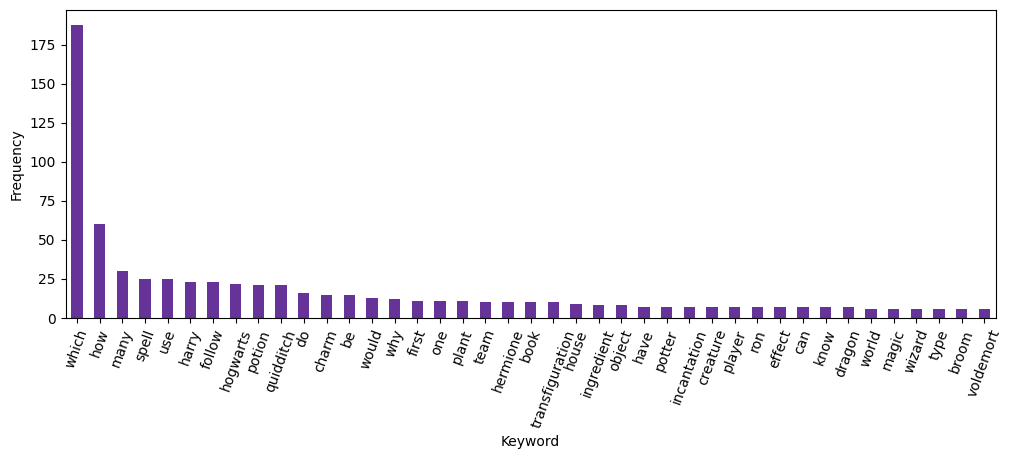

In [52]:
# Filter for values greater than a threshold so the chart isn't cluttered by the tail
threshold = 5
high_frequency_tokens = na_q_counts[na_q_counts > threshold]

high_frequency_tokens.plot(kind='bar', figsize=(12,4), color='rebeccapurple')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
# plt.title(f"Figure {figure_count}. Kewyords that occur with a frequency greater then {frequency_cutoff} in the dataset (question and answer combined)")
plt.xticks(rotation=70)
plt.show()

#### Analysis of keyword frequencies of the unassigned questions

1. **Expand the interrogative keywords list**: the most frequent keywords are interrogatives (such as "which", "how", "why") and auxiliary verbs (like "be", "do", "would"). 

2. **Prevalence of `which`**: The keyword `which` is the most common by a significant margin. These questions would typically be factual-recall types (e.g. "Which spell did Harry use to ...?") or multiple-choice questions ("Which of the following...?").

3. **Yes/No and descriptive questions**: The high frequency of the lemmatized verb `be` (representing "is," "are," "was," etc.) points to a large number of questions that are either yes/no inquiries or ask for a simple description (e.g., "Is Hermione the brightest witch?").

4. **More numerical questions**: Seeing both `how` and `many` could indicate quantitative questions. These would be another type of factual-recall type when they appear together. However, `how` on its own could be open-ended as well, asking to explain how something works or how an event came about.

5. **Rich Domain-Specific Context**: The dataset again shows terms specific to the Harry Potter universe. Tokens such as 'spell,' 'hogwarts,' 'quidditch,' 'hermione,' and 'voldemort' confirm that the questions are specific and context-dependent.

6. **Follows main distribution pattern**: Similar to the overall pattern, the keyword frequencies exhibit a classic long-tail or Zipfian distribution. A few words appear with very high frequency, while the vast majority appear rarely. This highlights that a small core vocabulary drives most of the questions in the dataset.

We can now update the keyword list and rename the keyword list and `factual_recall_keywords` column to be for general `interrogative` terms. We then need to tokenize the dataset with the new list and evaluate the new token additions individually.

In [53]:
# Create a copy of the trivia_keywords_df for further processing
df_processed_v0 = trivia_keywords_df.reset_index(names='original_question_id').copy()

# updated interrogative keyword list:
interrogative_wordlist = ['what', 'name', 'who', 'where', 'when', 'which', 'whom', 'whose', 'why', 'how', 'be', 'do', 'can']

# overwrite the 'factual_recall_keyword' column with the updated keyword list
df_processed_v0 = eda.tag_questions_by_keyword_list(
    df=df_processed_v0,
    keyword_column='question tokens',
    trigger_keyword_list=interrogative_wordlist,
    new_column_name='interrogative_keywords'
)
    
df_processed_v0['main_keyword'] = df_processed_v0['interrogative_keywords'].apply(obs.get_main_keyword_v0_obsolete)

# Drop the old, redundant column
df_processed_v0 = df_processed_v0.drop(columns=['factual_recall_keyword'], errors='ignore')

# quick check of how many 'unassigned' questions remain
print(f"There are {df_processed_v0[df_processed_v0['main_keyword'] == 'unassigned'].shape[0]} 'unassigned' questions remaining in the dataset.")

# Sanity check
df_processed_v0.sample(5, random_state=16)

There are 13 'unassigned' questions remaining in the dataset.


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords
169,169,How is the Grey Lady related to Rowena Ravenclaw?,She's Rowena's daughter.,"[how, grey, lady, relate, rowena, ravenclaw]","[rowena, daughter]","[how, grey, lady, relate, rowena, ravenclaw, daughter]",how,[how]
467,467,Where is Ovomancy thought to originate?,Ancient Greece,"[where, ovomancy, think, originate]","[ancient, greece]","[where, ovomancy, think, originate, ancient, greece]",where,[where]
270,270,What magical plant allows humans to breathe underwater?,Gillyweed,"[what, magical, plant, allows, humans, breathe, underwater]",[gillyweed],"[what, magical, plant, allows, humans, breathe, underwater, gillyweed]",what,[what]
593,593,Which statement is true about conjured objects?,They vanish in time,"[which, statement, true, conjure, object]","[vanish, time]","[which, statement, true, conjure, object, vanish, time]",which,[which]
244,244,What did Hagrid name his pet dragon?,Norbert,"[what, hagrid, name, pet, dragon]",[norbert],"[what, hagrid, name, pet, dragon, norbert]",what,"[what, name]"


In [54]:
df_processed_v0[df_processed_v0['main_keyword'] == 'unassigned']

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords
103,103,Did Muggles use ancient runes as well?,They did.,"[muggles, use, ancient, rune, well]",[],"[muggles, use, ancient, rune, well]",unassigned,[]
355,355,True or false: Harry Potter and the Deathly Hallows: Part Two is the shortest Harry Potter movie.,True! The run time is just 130 minutes.,"[true, false, harry, potter, deathly, hallows, part, two, shortest, movie]","[true, run, time, 130, minute]","[true, false, harry, potter, deathly, hallows, part, two, shortest, movie, run, time, 130, minute]",unassigned,[]
489,489,Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse.,Bind (Got this in the Petrificus Totalus lesson.),"[fill, blank, petrificus, totalus, incantation, full, body, bind, curse]","[bind, get, petrificus, totalus, lesson]","[fill, blank, petrificus, totalus, incantation, full, body, bind, curse, get, lesson]",unassigned,[]
535,535,True or false: This is the longest movie in the franchise.,"False! Harry Potter and the Chamber of Secrets is the longest movie, at 161 minutes.","[true, false, long, movie, franchise]","[false, harry, potter, chamber, secret, longest, movie, 161, minute]","[true, false, long, movie, franchise, harry, potter, chamber, secret, longest, 161, minute]",unassigned,[]
565,565,Wich of these creatures is notable proud and easy to offend if not treated politely?,Hippogriff,"[wich, creature, notable, proud, easy, offend, treat, politely]",[hippogriff],"[wich, creature, notable, proud, easy, offend, treat, politely, hippogriff]",unassigned,[]
591,591,The Bouncy Bulb is extremely difficult to...,Pot.,"[bouncy, bulb, extremely, difficult]",[pot],"[bouncy, bulb, extremely, difficult, pot]",unassigned,[]
651,651,Is it safe to drink water conjured by Aguamenti?,"Yes, it's safe to drink.","[safe, drink, water, conjure, aguamenti]","[yes, safe, drink]","[safe, drink, water, conjure, aguamenti, yes]",unassigned,[]
727,727,"You may have heard that Luna Lovegood wears shoes to bed, but does anyone know the reason?",She sleepwalks,"[may, have, hear, luna, lovegood, wear, shoe, bed, anyone, know, reason]",[sleepwalks],"[may, have, hear, luna, lovegood, wear, shoe, bed, anyone, know, reason, sleepwalks]",unassigned,[]
805,805,Did the werewolf code of conduct work?,No,"[werewolf, code, conduct, work]",[],"[werewolf, code, conduct, work]",unassigned,[]
907,907,Is it safe to eat mistletoe berries?,"No, they're poisonous.","[safe, eat, mistletoe, berry]",[poisonous],"[safe, eat, mistletoe, berry, poisonous]",unassigned,[]


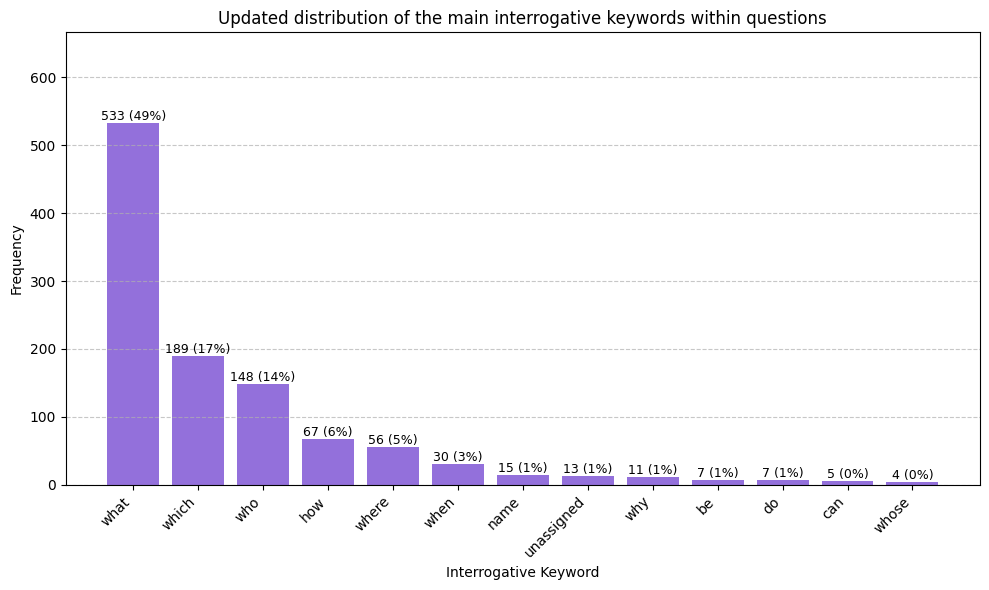

In [55]:
# Plot the updated distribution of the main interrogative keywords within questions uing the custom method from eda_scripts
total_questions = trivia_keywords_df.shape[0]
main_fr_keyword_counts = df_processed_v0['main_keyword'].value_counts()
eda.plot_categorical_distribution(main_fr_keyword_counts, total_questions,
                              "Updated distribution of the main interrogative keywords within questions",
                              "Interrogative Keyword")

#### Analysis of the updated keyword distribution

The updated classification logic has improved the granularity of the keyword distribution. The most impactful change is the reassignment of the large "unassigned" category.

1. **Drastic reduction of "unassigned" questions**: The updated keyword list has improved classification, reducing the 'unassigned' question count from 280 questions (26%) to only 4 questions (less than 1%).

2. **`Which` questions are a major category**: The most significant new category is `which`, which now accounts for 177 questions (16%), making it the second-largest group. These could be a combination of both factual-recall types and multiple-choice questions and will be investigated further.

3. **Reassignment of `what` questions**: The `what` category saw a notable drop from 545 to 503 questions. This suggests that about 42 questions previously classified as what were reassigned to other categories during the update. It could either be an improvement or because `be` and `do` being slightly noisy. This needs to be investigated further and the category assignment logic may need to be refined to prioritize interrogative pronouns (what, which, who) over auxiliary verbs (is, do) when both are present at the start of a question.

4. **New keyword categories**: The update also identified several smaller keyword categories and questions types that were previously hidden:
    - `how`: 66 questions (6%), could be a combination of factual type and explanatory.
    - `be`: 65 questions (6%), likely yes/no or simple descriptive questions.
    - `do`: 14 questions (1%), also likely to be yes/no or simple descriptive questions.
    - `why`: 11 questions (1%), indicating a small number of explanatory questions.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#73-questions-that-do-not-have-factual-recall-keywords" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.3 Quick Links</a>

### 7.3.2: What do the "be" type questions look like?

In [56]:
# only 'be' questions
be_questions = df_processed_v0 [(df_processed_v0 ['main_keyword'] == 'be')&(df_processed_v0['interrogative_keywords'].str.len() ==1)]
print(f"There are {be_questions.shape[0]} questions that have 'be' as the only main keyword.")
be_questions

There are 0 questions that have 'be' as the only main keyword.


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords


In [57]:
# Define search terms
search_pair = {'what', 'be'}

# look for questions that contain both 'what' and 'be' in the 'interrogative_keywords' column and have 'be' as the main_keyword
results = df_processed_v0 [
    (df_processed_v0['interrogative_keywords'].apply(lambda kws: search_pair.issubset(kws))) &
    (df_processed_v0['main_keyword'] == 'be')]

# only 'be' questions
be_questions = df_processed_v0 [(df_processed_v0['main_keyword'] == 'be')&(df_processed_v0['interrogative_keywords'].str.len() ==1)]

# display results
count = len(results)
print(f"Found {count} questions that contain both 'what' and 'be' and have 'be' as the main keyword.")
results

Found 6 questions that contain both 'what' and 'be' and have 'be' as the main keyword.


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords
74,74,I'd be surprised if you knew this. what's the first step of flying on your broom?,Kicking off,"[be, surprise, know, what, first, step, fly, broom]",[kick],"[be, surprise, know, what, first, step, fly, broom, kick]",be,"[be, what]"
240,240,"To be allowed to Apparate, you must do what two things?",Be at least 17 years old and get your license.,"[be, allow, apparate, must, do, what, two, thing]","[be, least, 17, year, old, get, license]","[be, allow, apparate, must, do, what, two, thing, least, 17, year, old, get, license]",be,"[be, do, what]"
310,310,Thestrals are mistakenly considered to be omens of what?,Misfortune.,"[thestrals, mistakenly, consider, be, omen, what]",[misfortune],"[thestrals, mistakenly, consider, be, omen, what, misfortune]",be,"[be, what]"
358,358,"Oy, you'll be sure to remember this one. During our first day of Herbology class, what creature took the form of a werewolf and gave Penny Haywood a scare?",Boggart,"[oy, be, sure, remember, one, first, day, herbology, class, what, creature, take, form, werewolf, give, penny, haywood, scare]",[boggart],"[oy, be, sure, remember, one, first, day, herbology, class, what, creature, take, form, werewolf, give, penny, haywood, scare, boggart]",be,"[be, what]"
640,640,This topic will be included on what exam?,The N.E.W.T.S.,"[topic, be, include, what, exam]",[],"[topic, be, include, what, exam]",be,"[be, what]"
955,955,One's defences against the Dark Arts must be what?,Versatile,"[one, defences, dark, art, must, be, what]",[versatile],"[one, defences, dark, art, must, be, what, versatile]",be,"[be, what]"


- overlap between 'be' and 'what' question written in passive tone - so "what" appears later / end of the question rather that at the front. or they have a preceding sentence with context to the actual question.
- The overlap cases are all 'what' questions after reviewing all 38 questions. There needs to be a precedene tha what > be.

In [58]:
# Define search terms
search_terms = {'name', 'who', 'where', 'when', 'whats', 'which','why', 'how'}  # interrogative keywords without 'be' and 'do'

dfs_to_check = []
summary = {}

for term in search_terms:
    # look for questions that contain both the term and 'be' in the 'interrogative_keywords' column and have 'be' as the main_keyword
    term_result = df_processed_v0[
        (df_processed_v0['interrogative_keywords'].apply(lambda kws: {term, 'be'}.issubset(kws))) &
        (df_processed_v0['main_keyword'] == 'be')]
    
    if not term_result.empty:
        summary[term] = len(term_result)
        dfs_to_check.append(term_result)
        
# Display findings
print("Summary of 'be' questions that also contain another interrogative keyword:")
for term, count in summary.items():
    print(f"- Found {count} instances for the pair: {{{term}, 'be'}}")
all_dfs = pd.concat(dfs_to_check)
all_dfs.head()


Summary of 'be' questions that also contain another interrogative keyword:
- Found 1 instances for the pair: {which, 'be'}


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords
394,394,The Diricawl is actually thought to be which extinct Muggle bird?,The Dodo.,"[diricawl, actually, think, be, which, extinct, muggle, bird]",[dodo],"[diricawl, actually, think, be, which, extinct, muggle, bird, dodo]",be,"[be, which]"


There is a considerable overlap between interrogative pronouns (like `what` and `which`) and auxiliary verbs (like `is` and `are`). This typically happens when a question is written in a passive voice or is preceded by a contextual sentence, causing an auxiliary verb to appear before the primary interrogative word.

To resolve this ambiguity, a simple precedence rule will be applied: when both types of keywords appear in a question, the interrogative pronoun is the more important signal and takes priority. This will make the `main_keyword` assignment more robust and accurately reflect the true intent of the query. 

>**NOTE: Imporoved `main_keyword` tagging in v0.1**
>
>The initial version of the `get_main_keyword` function had a key limitation: it often failed to distinguish between primary interrogative pronouns (like 'what', 'where') and auxiliary verbs (like 'be'), which blurred the analysis of non-factual questions. This was resolved by implementing a precedence rule that correctly prioritizes the interrogative pronoun when both types of keywords are present. 
>
>**The the final, correct version resides in the main [eda_scripts.py module](../src/ds_utils/eda_scripts.py) and implemented from this point forward in the notebook to maintain the workflow**

So to implement, we need to retokenize the dataset with the updated methods.

In [59]:
# Create a copy of the trivia_keywords_df for further processing
df_processed = trivia_keywords_df.reset_index(names='original_question_id').copy()

# updated interrogative keyword list:
interrogative_wordlist = [ 
    # --- Priority 1 --- interrogative pronouns
    'what','which','who','how','where','when', 'why', 'name', 'whose', 'whom',
    # --- Priority 2 (Fallbacks) --- auxiliary verbs
    'be','do','can','would'
]

# overwrite the 'factual_recall_keyword' column with the updated keyword list
df_processed = eda.tag_questions_by_keyword_list(
    df=df_processed,
    keyword_column='question tokens',
    trigger_keyword_list=interrogative_wordlist,
    new_column_name='interrogative_keywords'
)
# repopulate the 'main_keyword' column using the updated 'interrogative_keywords' column
df_processed['main_keyword'] = df_processed['interrogative_keywords'].apply(eda.get_main_keyword)

# Drop the old, redundant column
df_processed = df_processed.drop(columns=['factual_recall_keyword'], errors='ignore')

# reassign df_for_analysis to the processed DataFrame
df_for_analysis = df_processed.copy()

# quick check of how many 'unassigned' questions remain
print(f"There are {df_processed[df_processed['main_keyword'] == 'unassigned'].shape[0]} 'unassigned' questions remaining in the dataset.")

# Sanity check
df_processed.sample(5, random_state=16)

There are 13 'unassigned' questions remaining in the dataset.


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords
169,169,How is the Grey Lady related to Rowena Ravenclaw?,She's Rowena's daughter.,"[how, grey, lady, relate, rowena, ravenclaw]","[rowena, daughter]","[how, grey, lady, relate, rowena, ravenclaw, daughter]",how,[how]
467,467,Where is Ovomancy thought to originate?,Ancient Greece,"[where, ovomancy, think, originate]","[ancient, greece]","[where, ovomancy, think, originate, ancient, greece]",where,[where]
270,270,What magical plant allows humans to breathe underwater?,Gillyweed,"[what, magical, plant, allows, humans, breathe, underwater]",[gillyweed],"[what, magical, plant, allows, humans, breathe, underwater, gillyweed]",what,[what]
593,593,Which statement is true about conjured objects?,They vanish in time,"[which, statement, true, conjure, object]","[vanish, time]","[which, statement, true, conjure, object, vanish, time]",which,[which]
244,244,What did Hagrid name his pet dragon?,Norbert,"[what, hagrid, name, pet, dragon]",[norbert],"[what, hagrid, name, pet, dragon, norbert]",what,"[what, name]"


In [60]:
# Remaining 'unassigned' questions
df_processed[df_processed['main_keyword'] == 'unassigned']

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords
103,103,Did Muggles use ancient runes as well?,They did.,"[muggles, use, ancient, rune, well]",[],"[muggles, use, ancient, rune, well]",unassigned,[]
355,355,True or false: Harry Potter and the Deathly Hallows: Part Two is the shortest Harry Potter movie.,True! The run time is just 130 minutes.,"[true, false, harry, potter, deathly, hallows, part, two, shortest, movie]","[true, run, time, 130, minute]","[true, false, harry, potter, deathly, hallows, part, two, shortest, movie, run, time, 130, minute]",unassigned,[]
489,489,Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse.,Bind (Got this in the Petrificus Totalus lesson.),"[fill, blank, petrificus, totalus, incantation, full, body, bind, curse]","[bind, get, petrificus, totalus, lesson]","[fill, blank, petrificus, totalus, incantation, full, body, bind, curse, get, lesson]",unassigned,[]
535,535,True or false: This is the longest movie in the franchise.,"False! Harry Potter and the Chamber of Secrets is the longest movie, at 161 minutes.","[true, false, long, movie, franchise]","[false, harry, potter, chamber, secret, longest, movie, 161, minute]","[true, false, long, movie, franchise, harry, potter, chamber, secret, longest, 161, minute]",unassigned,[]
565,565,Wich of these creatures is notable proud and easy to offend if not treated politely?,Hippogriff,"[wich, creature, notable, proud, easy, offend, treat, politely]",[hippogriff],"[wich, creature, notable, proud, easy, offend, treat, politely, hippogriff]",unassigned,[]
591,591,The Bouncy Bulb is extremely difficult to...,Pot.,"[bouncy, bulb, extremely, difficult]",[pot],"[bouncy, bulb, extremely, difficult, pot]",unassigned,[]
651,651,Is it safe to drink water conjured by Aguamenti?,"Yes, it's safe to drink.","[safe, drink, water, conjure, aguamenti]","[yes, safe, drink]","[safe, drink, water, conjure, aguamenti, yes]",unassigned,[]
727,727,"You may have heard that Luna Lovegood wears shoes to bed, but does anyone know the reason?",She sleepwalks,"[may, have, hear, luna, lovegood, wear, shoe, bed, anyone, know, reason]",[sleepwalks],"[may, have, hear, luna, lovegood, wear, shoe, bed, anyone, know, reason, sleepwalks]",unassigned,[]
805,805,Did the werewolf code of conduct work?,No,"[werewolf, code, conduct, work]",[],"[werewolf, code, conduct, work]",unassigned,[]
907,907,Is it safe to eat mistletoe berries?,"No, they're poisonous.","[safe, eat, mistletoe, berry]",[poisonous],"[safe, eat, mistletoe, berry, poisonous]",unassigned,[]


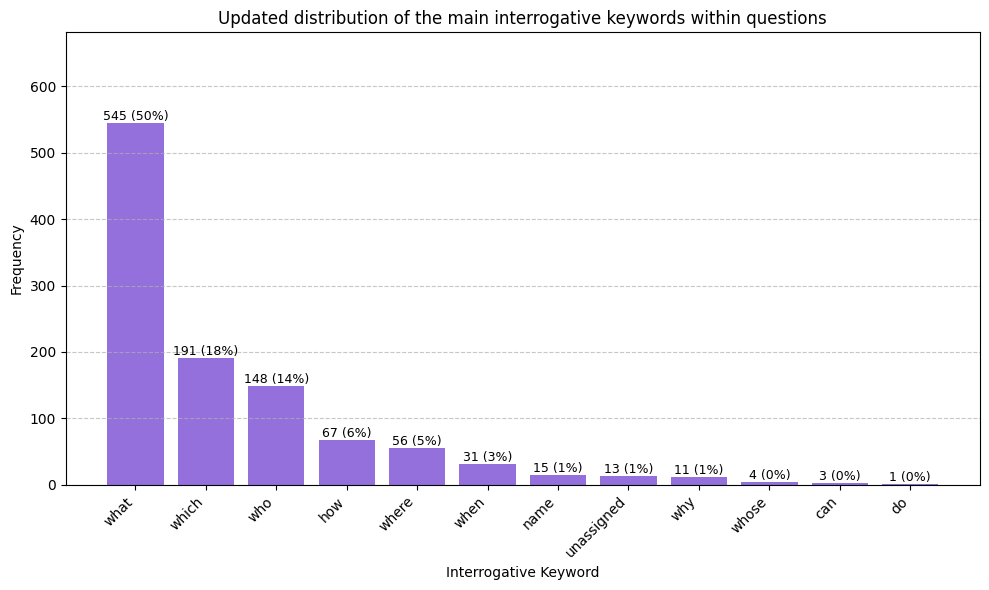

In [61]:
# Plot the updated distribution of the main interrogative keywords within questions uing the custom method from eda_scripts
total_questions = trivia_keywords_df.shape[0]
main_fr_keyword_counts = df_processed['main_keyword'].value_counts()
eda.plot_categorical_distribution(main_fr_keyword_counts, total_questions,
                              "Updated distribution of the main interrogative keywords within questions",
                              "Interrogative Keyword")

In [62]:
# remaning 'be' questions
only_be_questions = df_for_analysis[df_for_analysis['main_keyword']=='be']
only_be_questions

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords


The updated precedence rules have successfully refined the keyword classification.

1. **Near-complete coverage**:  Only one question remains unassigned. As it has been identified as invalid, it can be removed, resulting in 100% coverage for all valid questions.

2. **Overlap eliminated**: The counts for primary interrogative keywords (i.e. `what`, `who`, `where`, `when`, `name`) are almost identical to what they were before the addition of the auxilliary keywords (in the first iteration). This confirms the new logic has successfully resolved the classification overlap with auxiliary verbs.

3. **Accurate categorization**: As a result, the buckets for auxiliary verbs (be, do, can) are now significantly smaller and more accurately represent the true number of yes/no or auxiliary-led questions.

4. **Handling of `will`**: The single unassigned question used the keyword will. Since 'will' typically refers to future events, while trivia tests existing knowledge, it's an unsuitable keyword. As it only appears in this one invalid question, it can be safely ignored.

5. **Only `be` questions**: This is like a "catch-all" bucket. These are only a handful of questions (7 in total) and includes yes/no types (Q.651, Q.907), fill-in-the blanks (Q.489, Q.591), and True or False (Q.355, Q.535) types. These questions also highlight quality issues; one addition (Q.565) is here because `which` is spelt incorrectly and Q.355, Q.489, Q.535 are incomplete. 

Based on the frequencies, we can look at `which`, `how`, and `why` individually in greater detail. The remaining keywords with counts less than 5 can be looked at collectively.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#73-questions-that-do-not-have-factual-recall-keywords" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.3 Quick Links</a>

### 7.3.2: What do the "which" questions look like?
These are now the second-largest categories. It is likely that these are either factual-recall type or multiple choice.

## Analysis for Keyword: 'WHICH'

Number of Questions: 191 (17.6% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,10.08,2.09
Median,9.00,2.00
Std Dev,3.55,1.40
Min,4.00,1.00
Max,23.00,9.00
Skew,1.47,2.10



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.103)
* Pearson's r = 0.103, P-value = 0.156

Scatter Plot with Regression Line:


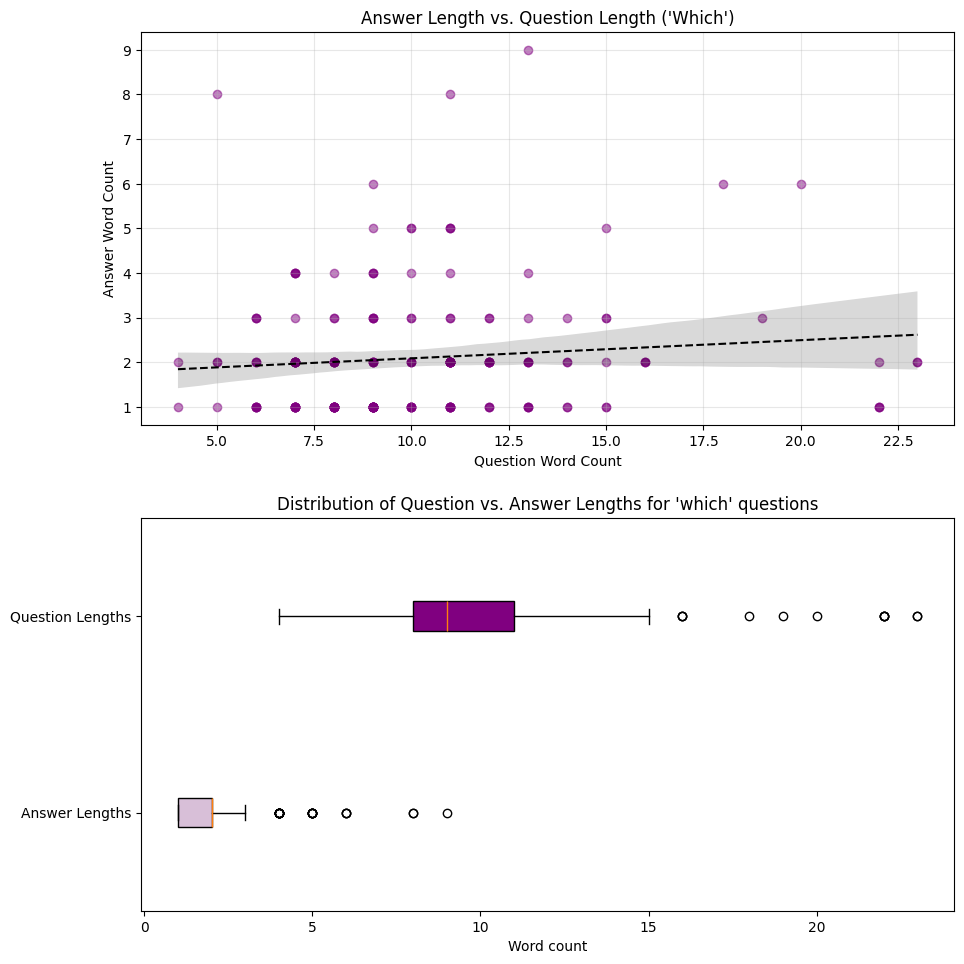


Random Sample (5) of 'which' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords
809,809,Which plant's pus clears up acne?,Bubotuber,"[which, plant, pu, clear, acne]",[bubotuber],"[which, plant, pu, clear, acne, bubotuber]",which,[which]
255,255,"In the Goblet of Fire, which two schools participate in the Triwizard Tournament alongside Hogwarts?",Durmstrang and Beauxbatons,"[goblet, fire, which, two, school, participate, triwizard, tournament, alongside, hogwarts]","[durmstrang, beauxbatons]","[goblet, fire, which, two, school, participate, triwizard, tournament, alongside, hogwarts, durmstrang, beauxbatons]",which,[which]
367,367,Which dark magic item is known as the friend of thieves?,Hand of Glory,"[which, dark, magic, item, know, friend, thief]","[hand, glory]","[which, dark, magic, item, know, friend, thief, hand, glory]",which,[which]
879,879,Which of these being does not live on the Hogwarts grounds?,Goblins,"[which, live, hogwarts, ground]",[goblin],"[which, live, hogwarts, ground, goblin]",which,[which]
645,645,Which of these spells would be most useful as an attack?,Engorgio,"[which, spell, would, be, useful, attack]",[engorgio],"[which, spell, would, be, useful, attack, engorgio]",which,"[which, would, be]"


----------------------------------------------------------------------


In [63]:
q_keyword = "which"
which_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(which_q_metrics, n_samples)

In [64]:
eda.print_keyword_ngrams(df_for_analysis['question'],'which',(2,4))


Analyzing common phrases (n-grams) starting with 'which' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'which':
- 'which of': 65
- 'which of these': 38
- 'which of the': 25
- 'which of the following': 22
- 'which of these is': 11
- 'which is': 10
- 'which of these spells': 8
- 'which potion': 7
- 'which spell': 7
- 'which incantation': 6


In [65]:
eda.print_keyword_ngrams(df_for_analysis['question'],"which",(5,10))


Analyzing common phrases (n-grams) starting with 'which' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'which':
- 'which of the following is': 8
- 'which of these is not': 6
- 'which of the following is not': 5
- 'which of these spells is': 4
- 'which of these is an': 3
- 'which of these is not type': 3
- 'which of these is not type of': 3
- 'which of these scenarios would': 3
- 'which of these scenarios would you': 3
- 'which of these scenarios would you use': 3


#### Analysis of the "which" questions

The `which` keyword makes up the second-largest category, making up 191 questions (17.6% of the total). The analysis indicates that these questions are primarily factual-recall questions that require short, specific answers, with many framed as multiple-choice.

1. **Short, factual answers**: The box plot and descriptive statistics show a median answer length of just 2 words, typical of what we've seen for factual-type questions.

2. **No statistical correlation in length**: As expected for factual-recall questions, there is no statistically significant correlation between question and answer length (p-value = 0.156). The complexity of the question's phrasing has no bearing on the simple, factual answer required.

3. **Mulitple choice questions**:  The samples and teh n-gram analysis indicates that a significant portion of these are likely multiple-choice questions. The phrases "which of these" (38 times) and "which of the following" (22 times) are very common would be followed by a list. Together, they account for nearly a third (31%) of all 'which' questions, confirming their nature as direct tests of knowledge.

4. **Data quality**: Here again we see that where we see any multiple-choice questions, they are incomplete. They start the questions but do not provide options to choose from.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#73-questions-that-do-not-have-factual-recall-keywords" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.3 Quick Links</a>

### 7.3.3: What do the "why" questions look like?
There aren't many `why` questions in the dataset but are most likely to be explanatory types that ilicit open-ended and semantically varied answers.

## Analysis for Keyword: 'WHY'

Number of Questions: 11 (1.0% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,8.82,5.91
Median,8.00,4.00
Std Dev,2.32,4.30
Min,5.00,2.00
Max,14.00,14.00
Skew,0.86,1.23



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.089)
* Pearson's r = 0.089, P-value = 0.796

Scatter Plot with Regression Line:


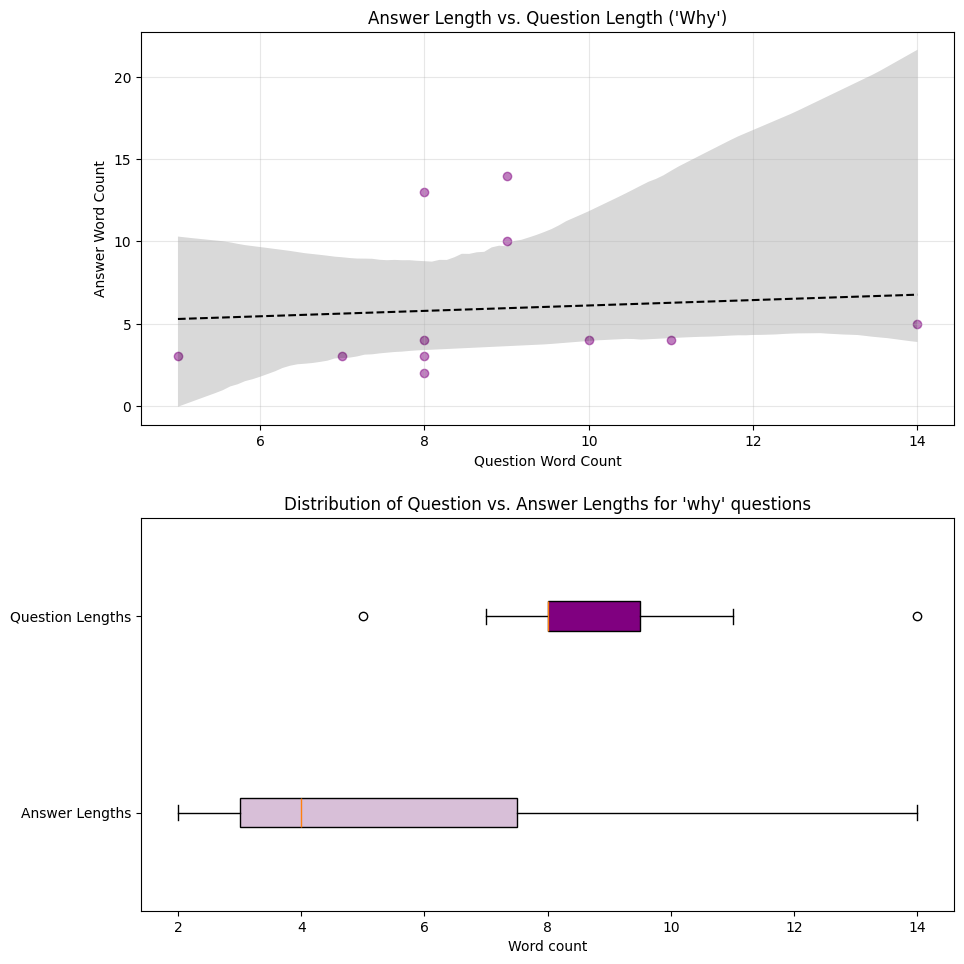


Random Sample (5) of 'why' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords
9,9,Why did student initially think Harry was the Heir of Slytherin?,He can speak Parseltongue,"[why, student, initially, think, harry, heir, slytherin]","[can, speak, parseltongue]","[why, student, initially, think, harry, heir, slytherin, can, speak, parseltongue]",why,[why]
876,876,Why shouldn't you drop Puffapod beans?,They'll bloom,"[why, drop, puffapod, bean]",[bloom],"[why, drop, puffapod, bean, bloom]",why,[why]
673,673,Why does Neville Longbottom faint in Herbology class?,"His earmuffs were loose, so he heard the cry of the baby mandrake.","[why, neville, longbottom, faint, herbology, class]","[earmuff, loose, hear, cry, baby, mandrake]","[why, neville, longbottom, faint, herbology, class, earmuff, loose, hear, cry, baby, mandrake]",why,[why]
508,508,Why would you cast Alohomora?,Unlock a door.,"[why, would, cast, alohomora]","[unlock, door]","[why, would, cast, alohomora, unlock, door]",why,"[why, would]"
104,104,Why did Liechtenstein not attend the first meeting of the International Confederation of Wizards?,Their Stance on Troll Rights,"[why, liechtenstein, attend, first, meet, international, confederation, wizard]","[stance, troll, right]","[why, liechtenstein, attend, first, meet, international, confederation, wizard, stance, troll, right]",why,[why]


----------------------------------------------------------------------


In [66]:
q_keyword = "why"
why_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(why_q_metrics, n_samples)

In [67]:
eda.print_keyword_ngrams(df_for_analysis['question'],'why', (2,4),5)


Analyzing common phrases (n-grams) starting with 'why' in this set of questions:
Using stop_words: None
Top 5 common n-grams starting with 'why':
- 'why did': 6
- 'why did the': 2
- 'why did the werewolf': 2
- 'why would': 2
- 'why would you': 2


In [68]:
stop_words = ['did', 'the', 'would' ,'do', 'does']
eda.print_keyword_ngrams(df_for_analysis['question'],'why',(2,3), 3, stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'why' in this set of questions:
Using stop_words: ['did', 'the', 'would', 'do', 'does']
Top 3 common n-grams starting with 'why':
- 'why werewolf': 2
- 'why werewolf code': 2
- 'why you': 2


#### Analysis of `why` questions:
The 11 'why' questions represent a small (1.0%) but distinct category in the dataset. Unlike the factual-recall types, these questions are designed to elicit explanations, motivations, and causes, leading to different answer structures.

1. **Longer explanatory answers**: The most noticeable characteristic is the answer length. With a median of 4 words and a mean of 5.9, the answers are considerably longer and more variable than what we've seen with the factual types. The n-gram analysis confirms this, showing that questions frequently start with 'why did...' or 'why would...', indicating a search for reasons. However, the answers remain concise, typically 1~2 sentences that provides a specific explanation, as seen in the example:
    >*Q.673 "Why does Neville Longbottom faint in Herbology class?" -> "His earmuffs were loose, so he heard the cry of the baby mandrake."* 

2. **Small sample size limits conclusions**: With such a small sample of questions, any statistical conclusion should be treated with caution. While there is no significant relationship between question and answer length (p-value ≈ 0.8), the wide confidence interval on the scatter plot visually highlights this uncertainty. The lack of correlation is likely because the answer needs to provide a specific explanation, the length of which is independent of the question's phrasing.

3. **Data quality insight - more missed duplicates**:  Questions Q.572 and Q.1045 are identical and can be considered duplicates but were not caught by the de-duplication step because of a minor variation in their answers ("it" added to one of the answers).  This insight suggests that future data cleaning could be improved by using semantic similarity scores to identify near-duplicates, rather than relying only on exact text matches.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#73-questions-that-do-not-have-factual-recall-keywords" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.3 Quick Links</a>

### 7.3.4: What do the "how" type questions look like?

## Analysis for Keyword: 'HOW'

Number of Questions: 67 (6.2% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,10.33,3.33
Median,9.00,2.00
Std Dev,4.65,4.72
Min,4.00,1.00
Max,27.00,25.00
Skew,1.41,3.25



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.039)
* Pearson's r = 0.039, P-value = 0.753

Scatter Plot with Regression Line:


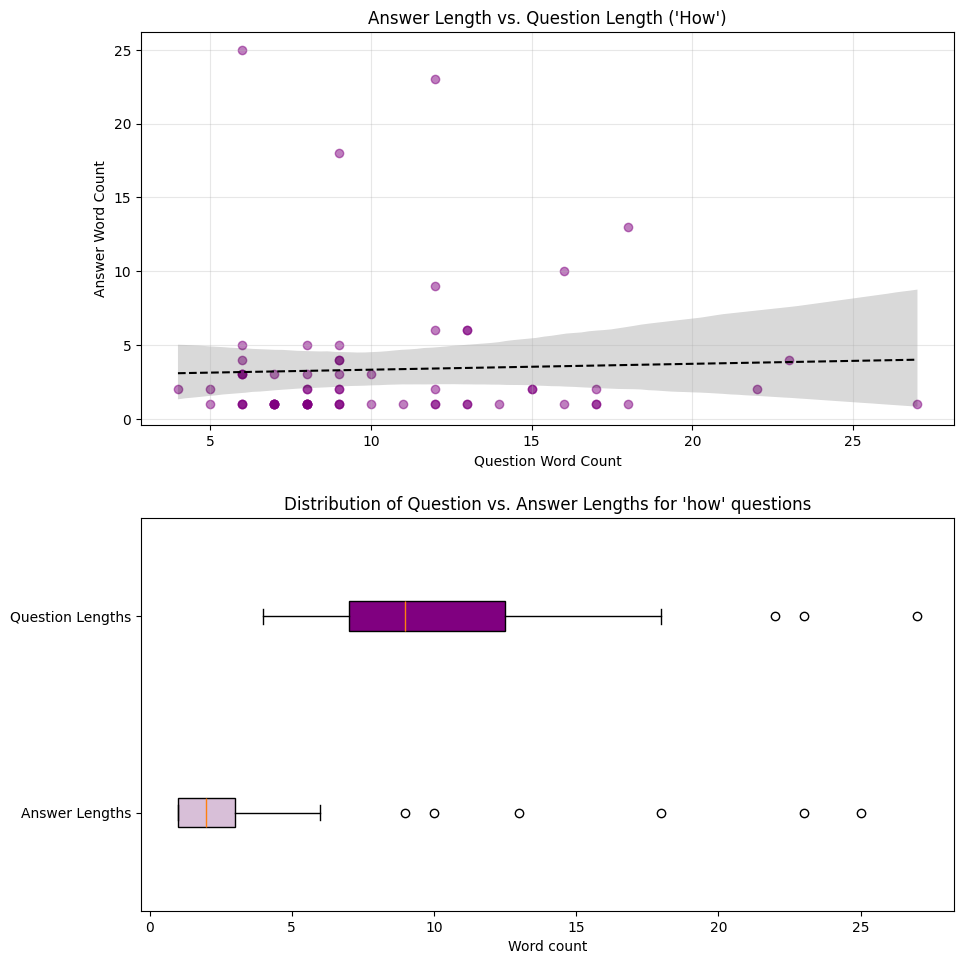


Random Sample (5) of 'how' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords
819,819,How do fairies communicate?,By buzzing.,"[how, do, fairy, communicate]",[buzzing],"[how, do, fairy, communicate, buzzing]",how,"[how, do]"
918,918,How much gold do the Weasleys win in the Daily Prophet Grand Prize Galleon Draw?,700 galleons,"[how, much, gold, do, weasleys, win, daily, prophet, grand, prize, galleon, draw]","[700, galleon]","[how, much, gold, do, weasleys, win, daily, prophet, grand, prize, galleon, draw, 700]",how,"[how, do]"
446,446,How many players are on a Quidditch team?,7,"[how, many, player, quidditch, team]",[],"[how, many, player, quidditch, team]",how,[how]
171,171,How do you greet a Hippogriff?,With a bow,"[how, do, greet, hippogriff]",[bow],"[how, do, greet, hippogriff, bow]",how,"[how, do]"
193,193,"In Harry Potter and the Prisoner of Azkaban, how do Hermione, Harry, and Ron find Crookshanks?",He jumps on Ron's head at the Magical Menagerie.,"[harry, potter, prisoner, azkaban, how, do, hermione, ron, find, crookshanks]","[jump, ron, head, magical, menagerie]","[harry, potter, prisoner, azkaban, how, do, hermione, ron, find, crookshanks, jump, head, magical, menagerie]",how,"[how, do]"


----------------------------------------------------------------------


In [69]:
q_keyword = "how"
how_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(how_q_metrics, n_samples)

In [70]:
eda.print_keyword_ngrams(df_for_analysis['question'],'how',(2,4))


Analyzing common phrases (n-grams) starting with 'how' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'how':
- 'how many': 31
- 'how do': 7
- 'how old': 6
- 'how does': 5
- 'how is': 5
- 'how did': 4
- 'how many times': 4
- 'how old was': 4
- 'how do you': 3
- 'how long': 3


In [71]:
stop_words = ['is', 'do', 'does', 'did', 'was', 'do']
eda.print_keyword_ngrams(df_for_analysis['question'],'how',(2,4), 5, stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'how' in this set of questions:
Using stop_words: ['is', 'do', 'does', 'did', 'was', 'do']
Top 5 common n-grams starting with 'how':
- 'how many': 31
- 'how old': 6
- 'how many times': 4
- 'how long': 3
- 'how many players': 3


#### Analysis of 'how` questions:
The analysis of `how` questions reveals them to be a hybrid category, containing a mix of simple factual queries and more complex explanatory questions.

1. **Two question types**: While many `how` questions are factual, the answer length distribution is skewed towards longer responses (mean 3.4 vs. median 2.0), indicating two different underlying question types:
    - **Factual & Quantitative**: A large portion seek a specific quantity. This is confirmed by common n-grams like `how many`, `how old`, and `how` long. The answers are often numerical but may include units or qualifiers (e.g., "500 galleons" or "about 30").
    - **Explanatory**: A significant number of questions seek a brief explanation. This is supported by the longer tail in the answer length distribution and phrases like `how do...`. Questions like *"How did Fred and George get the money to open their shop?"* require a causal explanation, not a simple fact.

2. **Again no length correlation**: across both subtypes, there is no statistically significant correlation between the length of the question and the length of the answer (p-value = 0.753).

3. **Identifying Open-Ended Clues:**: The analysis also highlighted how certain verbs can signal a more open-ended question. For example, the word describe in "How would you describe a Pixie's voice?" flags the question's intent, even if the provided answer is short.

For the current stage of analysis, all `how` questions will be pragmatically categorized as "factual-recall." This is an efficient initial classification but it intentionally overlooks some nuance. Therefore, this category is flagged for a future manual review to identify and correctly re-classify the more complex, open-ended questions.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#73-questions-that-do-not-have-factual-recall-keywords" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.3 Quick Links</a>

### 7.3.5: Remaining low frequency keywords
The remaining interrogative keywords (`whose`, `whom`, `do`, and `can`) all have very low frequencies, with fewer than five occurrences each. They can be analyzed in two logical groups:

1. **Other forms of 'who'**: The keywords `whose` (4 questions) and `whom` (2 questions) are the possessive and objective variations of `who`. They typically appear in more formally phrased questions.
2. **Yes/No auxiliary verbs**: Similar to `be`, the keywords `do` and `can` function as the primary interrogative word in questions that expect a simple yes/no answer.

#### 7.3.5.1: Other forms of the `who` keyword
Together there are only 6 questions using `whom` and `whose`. This is because the lemmatization step in the custom tokenizer, that uses *NLTK's WordNetLemmatizer*, doesn't recognize pronouns like `whose` and `whom`. 

>**NOTE: v0.1.0  Tokenizer upgrades**: 
>
>1. **Handling pronoun variations**:The initial analysis showed that keywords like `whom` and `whose` were not being grouped with their root word, `who`.This turned out to be a known nuance of the underlying *NLTK lemmatizer*, which is primarily designed for nouns, verbs, adjectives, and adverbs, and doesn't handle all pronoun cases by default. To resolve this a final step was added to tokenizer to normalize these specific pronouns.
>
> 2. **Modified process order**: After successfully ingesting all the new questions in the first iteration of v1, a final review of the dataset's status map showed an inconsistency. One question ("Did Muggles use ancient runes as well??") had no assigned interrogative keywords but was still correctly typed as a YN (Yes/No) question. The root cause turned out to be an error in order of operations in the original tokenizer. The tokenizer waas removing stop words before lemmatization, i.e. dropping "did" before it could be converted to its base form, "do". The tokenizier process was reordered accordinlgy. This in turn required a full refactoring of all downstream features and models (including the TF-IDF vectorizer) to maintain data consistency.
>
>**From this point forward, the analysis will use this refined custom tokenizer ([`tokenize_text`](../src/ds_utils/text_processing.py))  to ensure greater consistency.**

In [72]:
# Other forms of who questions
other_whotype_questions = df_for_analysis[(df_for_analysis['main_keyword']=='whose')|(df_for_analysis['main_keyword']=='whom')]
other_whotype_questions

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,main_keyword,interrogative_keywords
28,28,"""Lemon Drop"" is the password to whose office?",Dumbledore,"[lemon, drop, password, whose, office]",[dumbledore],"[lemon, drop, password, whose, office, dumbledore]",whose,[whose]
135,135,"On his first ride aboard the Hogwarts Express, whose card did Harry get with his chocolate frog?",Dumbledore,"[first, ride, aboard, hogwarts, express, whose, card, harry, get, chocolate, frog]",[dumbledore],"[first, ride, aboard, hogwarts, express, whose, card, harry, get, chocolate, frog, dumbledore]",whose,[whose]
603,603,"Whose teeth did Nearly Headless Nick accidentally turn into tusks, leading to his death?",Lady Grieve,"[whose, teeth, nearly, headless, nick, accidentally, turn, tusk, lead, death]","[lady, grieve]","[whose, teeth, nearly, headless, nick, accidentally, turn, tusk, lead, death, lady, grieve]",whose,[whose]
825,825,"In Harry Potter and the Prisoner of Azkaban, whose portrait replaces the Fat Lady after she is attacked?",Sir Cadogan,"[harry, potter, prisoner, azkaban, whose, portrait, replace, fat, lady, attack]","[sir, cadogan]","[harry, potter, prisoner, azkaban, whose, portrait, replace, fat, lady, attack, sir, cadogan]",whose,[whose]


The tokenizer has now been updated, we need to now retokenize and reprocess our dataset and confirm the results.

In [73]:
# create a copy of trivia_df
trivia_keywords_df_v2 = trivia_df.reset_index(names='original_question_id').copy()

# Create unique 'keywords' column by tokenizing 'question', 'answer', and combined (question, answer) with the custom tokenizer using a custom method from eda_scripts
trivia_keywords_df_v2 = eda.create_token_columns(trivia_keywords_df_v2, tokenizer=tokenize_text)

# create the 'interrogative_keyword' column 
trivia_keywords_df_v2 = eda.tag_questions_by_keyword_list(
    df=trivia_keywords_df_v2,
    keyword_column='question tokens',
    trigger_keyword_list= const.INTERROGATIVE_KEYWORDS_LIST,
    new_column_name='interrogative_keywords'
)
# repopulate the 'main_keyword' column using the 'interrogative_keywords' column
trivia_keywords_df_v2['main_keyword'] = trivia_keywords_df_v2['interrogative_keywords'].apply(eda.get_main_keyword)

# reassign df_for_analysis to the updated, processed DataFrame
df_for_analysis = trivia_keywords_df_v2.copy()

# Sanity check
df_for_analysis.sample(5, random_state=16)

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword
169,169,How is the Grey Lady related to Rowena Ravenclaw?,She's Rowena's daughter.,"[how, be, grey, lady, relate, rowena, ravenclaw]","[rowena, daughter]","[how, be, grey, lady, relate, rowena, ravenclaw, daughter]","[how, be]",how
467,467,Where is Ovomancy thought to originate?,Ancient Greece,"[where, be, ovomancy, think, originate]","[ancient, greece]","[where, be, ovomancy, think, originate, ancient, greece]","[where, be]",where
270,270,What magical plant allows humans to breathe underwater?,Gillyweed,"[what, magical, plant, allows, human, breathe, underwater]",[gillyweed],"[what, magical, plant, allows, human, breathe, underwater, gillyweed]",[what],what
593,593,Which statement is true about conjured objects?,They vanish in time,"[which, statement, be, true, conjured, object]","[vanish, time]","[which, statement, be, true, conjured, object, vanish, time]","[which, be, true]",which
244,244,What did Hagrid name his pet dragon?,Norbert,"[what, do, hagrid, name, pet, dragon]",[norbert],"[what, do, hagrid, name, pet, dragon, norbert]","[what, do, name]",what


There is only one `unassigned` question remaining which we have already seen is incorrect. We can delete it now.

In [74]:
# Let's drop the unassigned - incorrect question
unassigned_q = df_for_analysis[df_for_analysis['main_keyword']=='unassigned']
print(f'Confirm count: {unassigned_q.shape[0]} and question id is {unassigned_q['original_question_id'].iloc[0]}')
print(f'Row at position 1079 before deletion:\n {df_for_analysis[['original_question_id', 'question', 'answer']].iloc[1079]}')
# remove the unassigned question
df_for_analysis = df_for_analysis[df_for_analysis['original_question_id'] != 1079]
df_for_analysis = df_for_analysis.reset_index(drop=True)
print(f'Row at position 1079 after deletion:\n {df_for_analysis[['original_question_id', 'question', 'answer']].iloc[1079]}')

Confirm count: 1 and question id is 1079
Row at position 1079 before deletion:
 original_question_id                                                       1079
question                Will you serve the great nation of Peevesland, soldier?
answer                                                           Sir, yes, sir!
Name: 1079, dtype: object
Row at position 1079 after deletion:
 original_question_id                                                               1080
question                Which of these plants are prone to slapping people in the face?
answer                                                                   Bouncing Bulbs
Name: 1079, dtype: object


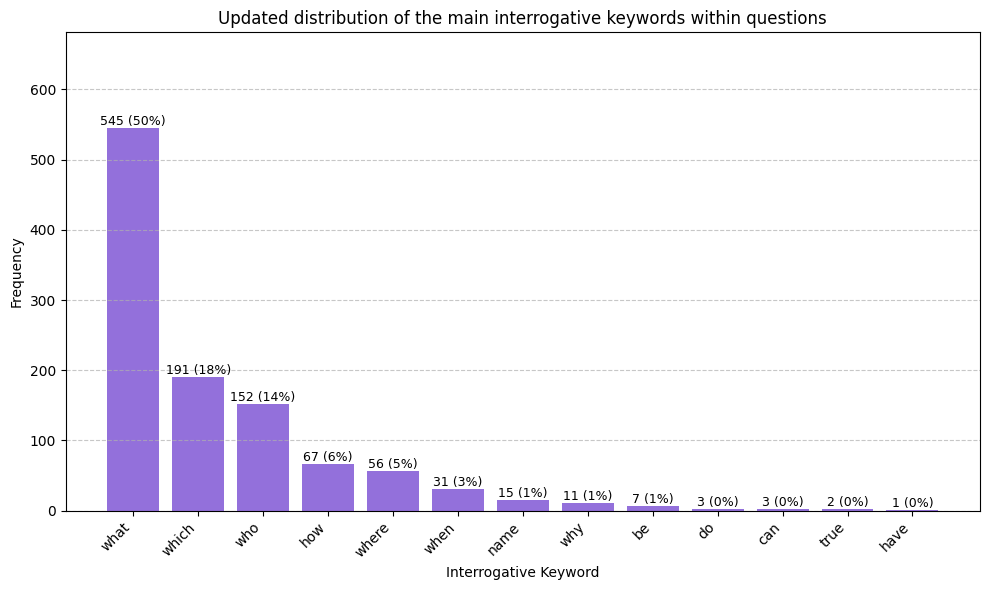

In [75]:
# Plot the updated distribution of the main interrogative keywords within questions uing the custom method from eda_scripts
total_questions = df_for_analysis.shape[0]
main_fr_keyword_counts = df_for_analysis['main_keyword'].value_counts()
eda.plot_categorical_distribution(main_fr_keyword_counts, total_questions,
                              "Updated distribution of the main interrogative keywords within questions",
                              "Interrogative Keyword")

**Improved categorization and tagging**

The count of the `who` column has increased by 4 (from 148 questions to 152) and the `whom` and `whose` categories have disappeared. This indicates that the `who` can now accomodate the `whose` and `whom` variations correctly. There are also no more 'unassigned' questions since the only question in this category was incorrect and has been removed. The result is clear, accurate, and meaningful categorization of the whole dataset through their main interrogative keyword, which generally is also indicative of the type of question (e.g. factual, explanatory, yes/no, etc).

#### 7.3.5.2: Remaining yes/no auxilliary verbs 
These are the remaining 9 questions across four marginal bins (`do`, `can`, `true`, and `have`). Let's have quick review of these:

In [76]:
# The remaining auxilliary verb questions
kw_list = ['do', 'can', 'true', 'have']
remainaing_questions = df_for_analysis[df_for_analysis['main_keyword'].isin(kw_list)]
remainaing_questions

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword
103,103,Did Muggles use ancient runes as well?,They did.,"[do, muggles, use, ancient, rune, well]",[do],"[do, muggles, use, ancient, rune, well]",[do],do
355,355,True or false: Harry Potter and the Deathly Hallows: Part Two is the shortest Harry Potter movie.,True! The run time is just 130 minutes.,"[true, false, harry, potter, deathly, hallows, part, two, be, short, movie]","[true, run, time, be, 130, minute]","[true, false, harry, potter, deathly, hallows, part, two, be, short, movie, run, time, 130, minute]","[true, false, be]",true
535,535,True or false: This is the longest movie in the franchise.,"False! Harry Potter and the Chamber of Secrets is the longest movie, at 161 minutes.","[true, false, be, long, movie, franchise]","[false, harry, potter, chamber, secret, be, long, movie, 161, minute]","[true, false, be, long, movie, franchise, harry, potter, chamber, secret, 161, minute]","[true, false, be]",true
676,676,Can the Extinguishing Charm be used to put out dragon fire?,"Yes, it can.","[can, extinguishing, charm, be, use, put, dragon, fire]","[yes, can]","[can, extinguishing, charm, be, use, put, dragon, fire, yes]","[can, be]",can
727,727,"You may have heard that Luna Lovegood wears shoes to bed, but does anyone know the reason?",She sleepwalks,"[may, have, hear, luna, lovegood, wear, shoe, bed, do, anyone, know, reason]",[sleepwalk],"[may, have, hear, luna, lovegood, wear, shoe, bed, do, anyone, know, reason, sleepwalk]","[have, do]",have
797,797,Can Ascendio be used underwater?,"Yes, it can","[can, ascendio, be, use, underwater]","[yes, can]","[can, ascendio, be, use, underwater, yes]","[can, be]",can
803,803,"Dittany, mixed with this ingredient, can cure a Werewolf bite.",Powdered Silver,"[dittany, mixed, ingredient, can, cure, werewolf, bite]","[powder, silver]","[dittany, mixed, ingredient, can, cure, werewolf, bite, powder, silver]",[can],can
805,805,Did the werewolf code of conduct work?,No,"[do, werewolf, code, conduct, work]",[no],"[do, werewolf, code, conduct, work, no]",[do],do
933,933,Do ancient runes have magical properties themselves?,"No, they don't.","[do, ancient, rune, have, magical, property]",[no],"[do, ancient, rune, have, magical, property, no]","[do, have]",do


The question classifier is working well, incluing cases where the questions are not clearly phrased. For example, in Q.727 (*"You may have heard that Luna Lovegood wears shoes to bed, but does anyone know the reason?"*), the `main_keyword` assigned here is `have`, while the more intuitive choice would be 'do'. However the question was still categorized correctly as a YN type. It also handled a variety of sentence structures, including questions with embedded interrogatives. The logic was able to robustly handle various structures, including simple yes/no formats (*"Did the werewolf..."*), sentences with embedded interrogatives (*"...but does anyone know..."*), and even "fill-in-the-blank" style questions phrased as statements. It is interesting to note that with `can` we were able to pick up the question that is written as a declarative sentence like Q.803: "*Dittany, mixed with this ingredient, can cure a Werewolf bite. A: Powdered Silver*".

With this we can conclude the interrogative keyword analysis and use it to identify the next course of action.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#73-questions-that-do-not-have-factual-recall-keywords" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.3 Quick Links</a>

## 7.4: Correlation Summary of Q&A Lengths by Keyword

The following table summarizes the correlation between question and answer lengths for each primary keyword. This breakdown will help identify any significant patterns.

In [77]:
# Keywords list of which terms to summarize in the table
keywords_list = ['what', 'which', 'who', 'how', 'where', 'when', 'name', 'why', 'be','do', 'can', 'have', 'true']
# List of keywords that will be categorized as 'factual recall'
FR_keywords = ['what', 'which', 'who', 'how', 'where', 'when', 'name' ]
# Create a master summary table based on keyword lists using a custom function from teh eda_scripts module
full_keyword_summary_df = eda.create_comprehensive_summary_df(keywords_list, FR_keywords, df_for_analysis)
# Display the correlation summary table using a view helper function from the eda_scripts module
eda.display_correlation_summary(full_keyword_summary_df)
# full_keyword_summary_df.columns

INFO: Correlation for 'do' skipped. All question (or answer) lengths are the same so there is no variance to measure.

Correlation Summary Table by Question Keywords:


,Question Keyword,question_type,Keyword Count,(%) of total,Mean Question Length,Mean Answer Length,Pearson's r,P-value,Interpretation
0,what,Factual-Recall,545,50.0,10.0,3.0,0.081,0.058,Not statistically significant (r=0.081)
1,which,Factual-Recall,191,18.0,10.0,2.0,0.103,0.156,Not statistically significant (r=0.103)
2,who,Factual-Recall,152,14.0,9.0,3.0,0.112,0.170,Not statistically significant (r=0.112)
3,how,Factual-Recall,67,6.0,10.0,3.0,0.039,0.753,Not statistically significant (r=0.039)
4,where,Factual-Recall,56,5.0,9.0,3.0,0.316,0.018,Statistically significant (correlation is Weak)
5,when,Factual-Recall,31,3.0,9.0,2.0,0.141,0.448,Not statistically significant (r=0.141)
6,name,Factual-Recall,15,1.0,13.0,7.0,-0.004,0.990,Not statistically significant (r=-0.004)
7,why,Non-Factual,11,1.0,9.0,6.0,0.089,0.796,Not statistically significant (r=0.089)
8,be,Non-Factual,7,1.0,11.0,4.0,0.188,0.686,Not statistically significant (r=0.188)
9,do,Non-Factual,3,0.0,7.0,2.0,NaN,NaN,Insufficient variance for correlation


1. **Not a significant feature**: the correlation between question and answer length is not a useful or reliable predictive feature. The relationship is either statistically insignificant or, in the one case it is significant (`where`), the correlation is too weak to be meaningful.The weak positive correlation (r=0.316) does make intuitive sense, a more complex question about a location might require a more specific (and thus slightly longer) answer. The borderline significance for `what` (p=0.058) with its large sample size suggests a tiny, almost negligible relationship exists.

2. **Answer length clearly segments question types**: The clearest pattern in this table is in the `Mean Answer Length` column. It cleanly separates your questions into two distinct groups:
    - *Short answer group (factual recall)*: Keywords like `which`, `when`, `what`, `who`, `how`, and `where` all have very short mean answer lengths (2-3 words). This numerically confirms they are seeking concise, specific facts.
    - *Long answer group (explanatory)*: Keywords like `why` have mean answer lengths that are twice as long (around 6 words). This validates that these questions are fundamentally different. `Name` likely results in longer answers because it requires a list of names. 

3. **Question length reveals unique phrasing**: While most questions are around 9-10 words long, two keywords stand out with much longer average question lengths:
    - `name` (13 words): This suggests that questions requiring a specific name are often phrased more formally or as commands (e.g., "Name the spell that is used to...").
    - `be` (11 words): Yes/no questions often require more context or setup (e.g., "Is it true that the Golden Snitch is worth 150 points in a game of Quidditch?"), making them longer than simple `what` or `who` questions.


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#73-questions-that-do-not-have-factual-recall-keywords" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 7.3 Quick Links</a>

## 7.5: N-gram Analysis of thematic content

While previous sections looked at n-grams for specific keywords, this analysis examines them across the entire dataset to gauge the depth of its Harry Potter content. The approach is twofold: first, we identify the top 20 most frequent n-grams to find the most common topics, and second, we use TF-IDF to discover phrases that are rare but thematically important

### 7.5.1: Top 20 n-grams in the questions

We can spot the most popular terms by looking at the most frequently occurring n-grams in the questions. Instead of relying on the processed keyword lists (`question tokens`) like before, this time we’re using the original, unprocessed question sentences to keep their natural phrasing intact. To do this, we use scikit-learn’s CountVectorizer, a simple and efficient tool that turns text into a matrix of token counts. This makes it easy to see the most common word combinations and get a clearer sense of the recurring themes in the dataset.

In [78]:
# custom method from eda_scripts tokenizes the column and counts frequencies of the common n-grams
eda.print_common_ngrams(df_for_analysis['question'],(2,4), top_n=20)


Analyzing common phrases (n-grams) in this series:
Top 20 common n-grams:
- 'harry potter': 48
- 'does harry': 17
- 'sorcerer stone': 13
- 'ministry magic': 12
- 'magical creature': 11
- 'triwizard tournament': 11
- 'quidditch team': 10
- 'did harry': 9
- 'draco malfoy': 9
- 'harry potter series': 9
- 'potter series': 9
- 'chamber secrets': 8
- 'common room': 8
- 'did hermione': 8
- 'professor snape': 8
- 'harry ron': 7
- 'hermione granger': 7
- 'polyjuice potion': 7
- 'does hermione': 6
- 'fred george': 6


The n-gram analysis confirms that the dataset is rooted in the Harry Potter universe. The most common phrases highlight a focus on key characters, major plot points, and core magical concepts, indicating that the questions cover the popular topics in the series. The findings can be broken down into a few key themes:

1. **Character centric questions**: The list is mostly character namess. This includes full names (`harry potter`, `draco malfoy`, `hermione granger`), character pairings (`harry ron`, `fred george`), and direct questions about their actions (`does harry`, `did hermione`). And as expected, phrases involving `harry potter` and `harry` are the most frequent confirming that he is the central subject of many trivia questions.

2. **Focus on major plot points.**: The n-grams reference significant events and objects, particularly from the early books in the series, such as `sorcerer stone` (the american title for the first book), `chamber secrets` (second book), `triwizard tournament` (fourth book), and polyjuice potion (in multiple books but first used in the second book).

3. **Other core Harry Potter concepts**: The common phrases also capture important places (`ministry magic`, `common room`) and activities (`quidditch team)`.

### 7.5.2: Top 20 n-grams in the answers

We can use the same approach to find the top 20 n-grams in the answers.

In [79]:
# custom method from eda_scripts tokenizes the column and counts frequencies of the common n-grams
eda.print_common_ngrams(df_for_analysis['answer'],(2,4), top_n=20)


Analyzing common phrases (n-grams) in this series:
Top 20 common n-grams:
- 'bloody baron': 8
- 'ministry magic': 6
- 'moaning myrtle': 6
- 'severus snape': 6
- 'sirius black': 6
- 'armando dippet': 5
- 'hermione granger': 5
- 'albus dumbledore': 4
- 'gilderoy lockhart': 4
- 'harry potter': 4
- 'horace slughorn': 4
- 'mimsy porpington': 4
- 'nicholas mimsy': 4
- 'nicholas mimsy porpington': 4
- 'patronus charm': 4
- 'wizard wheezes': 4
- '10th century': 3
- 'cho chang': 3
- 'chudley cannons': 3
- 'daily prophet': 3


The n-gram analysis of the answers requires highly specific, in-universe knowledge of Harry Potter. Unlike the questions, which contain other common words, the answers almost exclusively use Harry Potter terminology.

1. **Full names are most common**:  Majority of common answers are full character names that includes wizards, witches, and ghosts from the series, including the more the famous (`albus dumbledore`, `hermione granger`) to the obscure (`armando dippet`, `horace slughorn)`.

2. **Why is Bloody Baron at the top?**: It is a little suprising to see `bloody baron` as the top n-gram since he is not one of the main characters in the books. The high number could be because of a cluster of very-similar / near duplicate questions about him or it could be testing obscure logic about the ghosts that lead to the Bloody Baron. Or it could be a mixture of both but 8 does seem a little high. The same could be said about `armando dippet` appearing so many times.

3. **More specific Harry Potter context**: The answers also highlight specific magical concepts (patronus charm), places (wizard wheezes), and entities (daily prophet, chudley cannons), confirming the dataset's rich, domain-specific nature.

### 7.5.3: Identifying Significant N-grams with TF-IDF

The TF-IDF (Term Frequency-Inverse Document Frequency) can be used to uncover n-grams that are rare but also thematically important. This approach helps identify terms that are highly characteristic of specific questions, providing a more nuanced view of the dataset's content. For this analysis, a custom function efficiently uses the existing question and answer token columns, allowing the TF-IDF vectorizer to operate on already cleaned and processed text.

The two key parameters used are:
1. IDF score: This is a measure of the rarity, obscurity, and uniquness of the phrase. The higher the score the lower its occurence.
2. The summed tf-idf score: this is a measure of the overall importance of the phrase in the dataset. It sums the TF-IDF of an n-gram across all the documents.

#### 7.5.3.1: Answers
First, let's look at the answer column.

In [80]:
column_name = "answer tokens"

# Custom function
answer_tfidf_ngrams = eda.rank_ngrams_by_tfidf(df_for_analysis, column_name,(2,3))

# descriptive statistics
print('Descriptive statistics:\n', answer_tfidf_ngrams[['idf_score','summed_tfidf_score']].describe().round(2))

# rarest phrases
print('\n\nAnswer tokens n-grams sorted by rarity of n-gram (idf_score):\n\n', 
      answer_tfidf_ngrams.sort_values(by='idf_score', ascending=False).head(10))

# important phrases
print('\n\nAnswer tokens n-grams sorted by overall importance of n-gram (summed_tfidf_score):\n\n', 
      answer_tfidf_ngrams.sort_values(by='summed_tfidf_score', ascending=False).head(10))

Descriptive statistics:
        idf_score  summed_tfidf_score
count    1395.00             1395.00
mean        7.24                0.66
std         0.18                0.59
min         5.79                0.18
25%         7.30                0.30
50%         7.30                0.45
75%         7.30                1.00
max         7.30                8.00


Answer tokens n-grams sorted by rarity of n-gram (idf_score):

                         n-gram  idf_score  summed_tfidf_score
697                lethe water        7.3                1.00
887          normal thank much        7.3                0.20
907                    one who        7.3                0.38
906                  one month        7.3                1.00
905              one less last        7.3                0.20
904                   one less        7.3                0.20
901            old get license        7.3                0.30
900                    old get        7.3                0.30
899               

1. **The TF-IDF analysis** validates that the most significant answers in the dataset are the proper names of characters, places, and magical concepts. This is clearly demonstrated by the list of terms with the highest `summed_tfidf_score`, which features phrases like `bloody baron` and `ministry magic`. These terms strike the balance required by TF-IDF, i.e. they are rare enough to be distinctive (high IDF) and also appear frequently within their specific context (high Term Frequency).

2.  **Rare terms**: the list sorted only by rarity (`idf_score`) is however much noisier. It contains unique but unimportant fragments like `one who`, which are n-grams created when the updated tokenizer's lemmatization and stop word removal alter sentence structures.

The TF-IDF results validate that the most significant and characteristic answers in the dataset are the proper names of characters, places, and magical concepts.

#### 7.5.3.2: Questions

In [81]:
column_name = "question tokens"
question_tfidf_ngrams = eda.rank_ngrams_by_tfidf(df_for_analysis, column_name,(2,4))

# descriptive statistics
print('Descriptive statistics:\n', question_tfidf_ngrams[['idf_score','summed_tfidf_score']].describe().round(2))

# Rarest phrases
print('\n\nQuestion tokens n-grams sorted by rarity of n-gram (idf_score):\n\n', 
      question_tfidf_ngrams.sort_values(by='idf_score', ascending=False).head(10))

# Important phrases
print('\n\nAnswer tokens n-grams sorted by overall importance of n-gram (summed_tfidf_score):\n\n', 
      question_tfidf_ngrams.sort_values(by='summed_tfidf_score', ascending=False).head(10))

Descriptive statistics:
        idf_score  summed_tfidf_score
count   12567.00            12567.00
mean        7.23                0.32
std         0.23                0.36
min         2.62                0.15
25%         7.30                0.22
50%         7.30                0.26
75%         7.30                0.33
max         7.30               24.33


Question tokens n-grams sorted by rarity of n-gram (idf_score):

                                 n-gram  idf_score  summed_tfidf_score
0                              10 what        7.3                0.15
8117       professor mcgonagall enough        7.3                0.20
8106        professor harry first year        7.3                0.20
8107                professor hogwarts        7.3                0.37
8108              professor kettleburn        7.3                0.27
8109         professor kettleburn wish        7.3                0.27
8110  professor kettleburn wish retire        7.3                0.27
8112          

1. **Rare terms (IDF) reveal specific topics**: The list of phrases sorted by `idf_score` is much more informative for questions than it was for answers. This list contains specific and context-rich phrases that make up unique questions such as `professor mcgonagall`, `professor harry first year`. This provides a snapshot of the most unique and detailed topics within the dataset.

2. **Importance (TF-IDF) reveals question structure**: The list sorted by `summed_tfidf_score` is made up of the basic phrases like `what be`, `what do`, and `who be`. These phrases have a low idf_score (meaning they are very common), but their Term Frequency is so large that their overall importance score skyrockets, identifying them as the most significant patterns. This confirms the interrogative keyword analysis.

3. **Question identifier: content & structure**: While a specific noun like `harry` provides the context of a question, the TF-IDF analysis confirms that the fundamental building block that defines a sentence as a question in this dataset is the combination of an **interrogative word + a verb**.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 8: Summary of cleaning and EDA: 
This section summarizes the key findings from the exploratory data analysis and outlines the recommended next steps for the project.

## 8.1: Key findings and outcomes:

1. **Overview**: The dataset initially had 1279 rows and 3 columns. After cleaning this was reduced to 1085 rows and two columns (`question` and `answer`), with 194 rows dropped as duplicates. The original datasource from hugging face is no longer available but a local copy of the dataset is saved for reference. A online search and comparison indicated that the questions were primarily gathered through web-scrapping various online Harry Potter quizzes.

2. **Answer Length as an indicator of type**: While question lengths vary, the answer lengths provide significant insight. The distribution is right-skewed, with a median of 2 words, indicating that most answers are short and factual. A key finding is that answer length correlates with the question type:
    - Short answers (6 words or fewer) typically correspond to factual-recall questions.
    - Longer answers (7+ words) tend to be explanatory or contain lists, often in response to `why` or `how` questions.

3. **Iterative feature engineering was highly successful**: A robust categorization system was developed by creating a custom tokenizer and a priority-based method for assigning a main_keyword to each question. The process was iteratively improved to:
    - Retain key interrogative words during stop word removal.
    - Prioritize interrogative pronouns (e.g., `what`) over auxiliary verbs (e.g., `be`) to improve accuracy.
    - Normalize variations of `who` (`whom`, `whose`) by adding a custom rule to the lemmatization step.
    - Tokenizer lemmatize before removing removing stop words to make sure variations of the auxilliary verbs are not missed.
This resulted in a **complete, 100% categorization of all valid questions with informative labels**.

4. **Established Question Categories**: Based on the `main_keyword`, the questions can be grouped into distinct types, providing a clear blueprint for the trivia game's structure:
    - *Factual-Recall*: `what`, `which`, `who`, `where`, `when`, `how`, and `name`.
    - *Explanatory*: `why` and some instances of `how`.
    - *Multiple-Choice*: Primarily identified by the `which` keyword.
    - *Yes/No*: Includes *True/False* and *fill-in-the-blanks*, identified by auxiliary verbs like `be`, `do`, `can`, `have` and `true`.

5. **Question/Answer length correlation is unreliable**: The analysis confirmed that the relationship between question and answer length is too weak to be a reliable feature for categorization (overall p-value=0.02, r=0.09). When analyzed by `main_keyword`, the correlation was statistically insignificant in nearly all cases. 

6. **The dataset is contextually rich and thematically relevant**: was confirmed through multiple, complementary n-gram analyses. Examining the most frequent phrases revealed the core topics and characters, while TF-IDF analysis uncovered terms that were rare yet highly significant. Furthermore, a granular analysis within each keyword category provided deeper insight into how different question types are phrased.

7. **Some data quality issues discovered**: Through the EDA, some data quality issues were identified that included incomplete multiple choice questions, incorrect or irrelevant questions, some spelling mistakes, and missed near-duplicates. These issues will need to be addressed to ensure an enjoyable game experience for the player.

## 8.2: Next Steps and recommendations
Based on the findings from this analysis, the following actions are recommended:

1. **Create a 'Question Type' feature**: Implement the categorization logic to create a new feature in the dataset in four main categories (factual-recall, explanatory, mulitple-choice, and yes/no). Special attention will be required for the hybrid `how` questions to correctly distinguish between their factual and explanatory uses.

2. **Flag answer types**: Develop a methodology to identify and flag quantitative or uniquely formatted answers (dates, currencies, numbers) for special handling in the game logic. An example of special formatting is the Q.414 answer: "*6-2-4-4-2. (Bonus: This spells M-A-G-I-C on a phone's keypad.)*"

3. **Address Data-quality issuess**. To ensure a high-quality user experience within the trivia game, it is crucial to resolve the data quality issues identified during the EDA. This includes creating processes to handle:
    - Near-duplicate questions.
    - Incomplete multiple choice questions that are missing their list of answer options.
    - Questions with multiple answers that may need to be split or have their scoring logic adjusted. For example, e.g. Q.635 "This one is a two-parter. Where does Vernon Dursley work, and what does the company produce? Grunnings, a drill manufacturer." and Q.947 "In the wizarding world, speaking to snakes is a skill called what; famously practiced by who? Parsletoungue, Lord Voldemort"
    - incorrect and out-of-scope questions: e.g. questionable source (Q480. "Where do I- I mean, where does Tonks like to hide Jelly Slugs? Herbology Pots" ) and astronomy related questions (Q65. "Where can dark cloud constellations be most easily seen? Southern Hemisphere")

4. **Expand contextual analysis with NLP techniques**: For more advanced features, consider using techniques like custom Named Entity Recognition (NER) to automatically identify and tag specific entities like spells, characters, and locations within the text.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

### Future maintenance / updates
This section outlines the necessary procedures for maintaining the text processing components of this project to ensure long-term data consistency and model accuracy.

**Tokenizer Updates** Any future modifications to the tokenize_text function—such as updating stop words, changing the lemmatizer, or altering n-gram logic—will require a full refactoring of the dataset. To maintain data consistency, all downstream features and models must be regenerated. This includes:
- Re-tokenizing the entire dataset.
- Re-running the keyword and type classifiers.
- Re-training the TF-IDF vectorizer.

**Model Retraining (TfidfVectorizer)**: The TfidfVectorizer used for duplicate detection is sensitive to changes in the dataset's vocabulary. As new questions are added over time, the model will experience drift, and its accuracy will degrade. To combat this, the vectorizer must be periodically retrained.
- Retraining Trigger: A full retraining should be performed when approximately 500 new questions have been added since the last update.
- Process: This involves running a maintenance script that loads the entire current dataset, trains a new TfidfVectorizer from scratch, and saves it, overwriting the previous version.

---

### Exports for further analysis

**1. Updated Trivia dataframe** saved as a parquet file to keep the data type information.

In [82]:
# 💾 Checkpoint: Notebook 1 output dataframe 

output_path = nb_cfg.INTERMEDIATE_DATA_DIR / "dataframe_nb1_output_v0.parquet"

if not output_path.exists():
    print(f"File not found. Saving data to {output_path}...")
    df_for_analysis.to_parquet(output_path)
else:
    print(f"File {output_path.name} already exists. Skipping save.")

File dataframe_nb1_output_v0.parquet already exists. Skipping save.


**2. Key metrics for analysis in subsequent notebooks**

In [83]:
# metrics for other notebooks
initial_count = raw_df.shape[0]

# Create a dictionary to hold your metric(s)
metrics = {
    'raw_dataset_row_count': initial_count,
    'raw_dataset_column_count': raw_df.shape[1],
    'cleaned_dataset_row_count': trivia_df.shape[0],
    'cleaned_dataset_column_count': trivia_df.shape[1],
    'nb1_dataset_row_count': df_for_analysis.shape[0],
    'nb1_dataset_column_count': df_for_analysis.shape[1]
}
# Define the save path using your config
metrics_path = nb_cfg.METRICS_DIR/ "nb1_summary.json"

# Check if the file already exists before saving
if not metrics_path.exists():
    # If the file is not found, save the data
    print(f"File not found. Saving metrics to {metrics_path.name}...")
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f)
else:
    # If the file already exists, skip the save
    print(f"File {metrics_path.name} already exists. Skipping save.")

File nb1_summary.json already exists. Skipping save.


---

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#1-introduction" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Return to the Top</a>

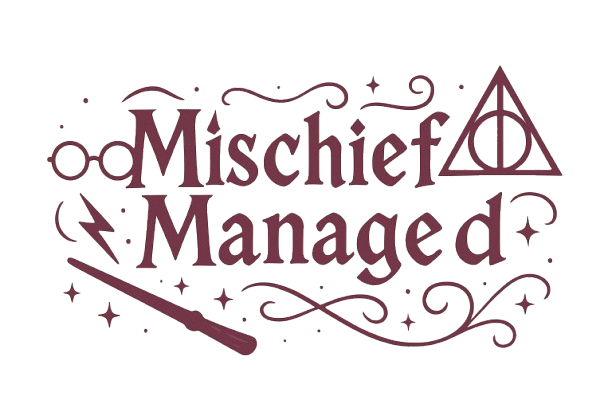